<style>
/* Thicken the divider line in VS Code's split view */
.monaco-workbench .split-view .resize-sash {
    width: 10px !important;
}
</style>

## intro a AI del curso de Kaggle

con el código de https://www.kaggle.com/learn-guide/5-day-genai?utm_medium=email&utm_source=gamma&utm_campaign=learn-5daygenai

### intro a genAI y prompting

In [53]:
from dotenv import load_dotenv
import os
from google.api_core import retry
from google import genai
from google.genai import types
from IPython.display import HTML, Markdown, display
import pandas as pd
# Ensure the required module is installed

is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

genai.models.Models.generate_content = retry.Retry(
    predicate=is_retriable)(genai.models.Models.generate_content)


# la llave API de Google ya fue agregada a .env

load_dotenv() 

GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')  # Retrieve the API key


In [54]:
# crea el cliente de GenAI

client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Explain AI to me like I'm a kid.")

print(response.text)

client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Explain AI to me like I'm a kid.")

print(response.text)

Okay, imagine you have a really smart puppy, but this puppy can't do anything on its own at first. It needs to learn everything!

**AI is like that puppy, but instead of fur and paws, it's made of computer code!**

Here's the thing:

*   **Learning from Examples:** We teach the puppy (AI) by showing it lots and lots of examples.  Like, if we want the puppy to know what a cat is, we show it thousands of pictures of cats!  The AI looks at all those pictures and figures out what things cats have in common - like pointy ears, whiskers, and furry tails.

*   **Making Predictions:** Once the AI has seen enough examples, it can start to guess! If you show it a new picture, it can say, "Hey, that looks like a cat!"  That's called making a prediction.

*   **Getting Better Over Time:** Every time the AI guesses right or wrong, it learns from its mistakes!  If it guesses "dog" when it's really a cat, we tell it, "No, that's a cat!"  Then it remembers that and tries to do better next time.

**Wha

In [55]:
Markdown(response.text)

Okay, imagine you have a really smart puppy! But instead of learning to fetch sticks, this puppy learns to do other things.

That's kind of like AI, which stands for Artificial Intelligence. It's like teaching a computer to think and learn, just like you do.

Here's how:

*   **Lots and Lots of Information:** You teach the puppy by showing it lots of things. "This is a ball," you say over and over. AI is similar! We give computers tons and tons of information to learn from, like millions of pictures of cats, or all the words in the dictionary.
*   **Finding Patterns:** The puppy starts to notice patterns. It sees that balls are round and bouncy. AI does the same thing, but with computers. It looks for patterns in all that information.
*   **Making Choices:** Based on what it's learned, the puppy can now choose to fetch a ball when you say "Fetch!" AI can also make choices based on what it's learned. For example, it can choose the best route to get you to school if you tell it where you are.
*   **Getting Better and Better:** The more the puppy practices, the better it gets at fetching. AI is the same! The more it learns and makes choices, the better it gets at solving problems.

So, AI is like teaching a computer to be really, really smart so it can help us with things like:

*   **Helping you find your favorite videos online.**
*   **Making video games more fun.**
*   **Helping doctors find ways to cure diseases.**
*   **Driving cars safely.**

It's like having a super-smart friend who can help us with almost anything! Just remember, it's not really a person, it's just a computer that's learned to do amazing things.


In [56]:
# # prueba de chat

# chat = client.chats.create(model='gemini-2.0-flash', history=[])
# response = chat.send_message('Hello! My name is Zlork.')
# print(response.text)

In [57]:
# response = chat.send_message('Can you tell me something interesting about dinosaurs?')
# print(response.text)

In [58]:
# response = chat.send_message('Do you remember what my name is?')
# print(response.text)

In [59]:
# from pprint import pprint

# for model in client.models.list():
#   if model.name == 'models/gemini-2.0-flash':
#     pprint(model.to_json_dict())
#     break

In [60]:
# # ajustar la longitud de la respuesta - en tokens!

# from google.genai import types

# short_config = types.GenerateContentConfig(max_output_tokens=200)

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=short_config,
#     contents='Write a 1000 word essay on the importance of olives in modern society.')
# response.text

In [61]:
# # ajustar temp del modelo

# high_temp_config = types.GenerateContentConfig(temperature=2.0)


# for _ in range(5):
#   response = client.models.generate_content(
#       model='gemini-2.0-flash',
#       config=high_temp_config,
#       contents='Pick a random colour... (respond in a single word)')

#   if response.text:
#     print(response.text, '-' * 25)

In [62]:
# # probar con temp baja

# low_temp_config = types.GenerateContentConfig(temperature=0.0)

# for _ in range(5):
#   response = client.models.generate_content(
#       model='gemini-2.0-flash',
#       config=low_temp_config,
#       contents='Pick a random colour... (respond in a single word)')

#   if response.text:
#     print(response.text, '-' * 25)

In [63]:
# top-p sampling devuelve las palabras más probables -- 

# model_config = types.GenerateContentConfig(
#     # These are the default values for gemini-2.0-flash.
#     temperature=1.0,
#     top_p=1.0,
# )

# story_prompt = "You are a creative writer. Write a short story about a cat who goes on an adventure."
# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=model_config,
#     contents=story_prompt)

# print(response.text)

#### prompting

In [64]:
# # zero-shot

# model_config = types.GenerateContentConfig(
#     temperature=0.1,
#     top_p=1,
#     max_output_tokens=5,
# )

# zero_shot_prompt = """Classify evaluations of movie subjects (ie, how the reviewer sees the object portrayed) as POSITIVE, NEUTRAL or NEGATIVE.
# Review: "Her" is a disturbing study revealing the direction
# humanity is headed if AI is allowed to keep evolving,
# unchecked. I wish there were more movies like this masterpiece.
# Sentiment: """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=model_config,
#     contents=zero_shot_prompt)

# print(response.text)

In [65]:
# # enum restringe el tipo de respuesta a un conjunto de valores predefinidos

# import enum

# class Sentiment(enum.Enum):
#     POSITIVE = "positive"
#     NEUTRAL = "neutral"
#     NEGATIVE = "negative"


# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         response_mime_type="text/x.enum",
#         response_schema=Sentiment
#     ),
#     contents=zero_shot_prompt)

# print(response.parsed)

In [66]:
# enum_response = response.parsed
# print(enum_response)
# print(type(enum_response))

In [67]:
# # one, few-shot
# few_shot_prompt = """Parse a customer's pizza order into valid JSON:

# EXAMPLE:
# I want a small pizza with cheese, tomato sauce, and pepperoni.
# JSON Response:
# ```
# {
# "size": "small",
# "type": "normal",
# "ingredients": ["cheese", "tomato sauce", "pepperoni"]
# }
# ```

# EXAMPLE:
# Can I get a large pizza with tomato sauce, basil and mozzarella
# JSON Response:
# ```
# {
# "size": "large",
# "type": "normal",
# "ingredients": ["tomato sauce", "basil", "mozzarella"]
# }
# ```

# ORDER:
# """

# customer_order = "Give me a large with cheese & pineapple"

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         temperature=0.1,
#         top_p=1,
#         max_output_tokens=250,
#     ),
#     contents=[few_shot_prompt, customer_order])

# Markdown(response.text)

In [68]:
# # forzar el formato de salida a json
# import typing_extensions as typing

# class PizzaOrder(typing.TypedDict):
#     size: str
#     ingredients: list[str]
#     type: str


# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         temperature=0.1,
#         response_mime_type="application/json",
#         response_schema=PizzaOrder,
#     ),
#     contents="Can I have a large dessert pizza with apple and chocolate")

# Markdown(response.text)

#### Chain of Thought

In [69]:
# prompt = """When I was 4 years old, my partner was 3 times my age. Now, I
# am 20 years old. How old is my partner? Return the answer directly."""

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=prompt)

# print(response.text)

In [70]:
# prompt = """When I was 4 years old, my partner was 3 times my age. Now,
# I am 20 years old. How old is my partner? Let's think step by step."""

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=prompt)

# Markdown(response.text)

In [71]:
# # REACT
# model_instructions = """
# Solve a question answering task with interleaving Thought, Action, Observation steps. Thought can reason about the current situation,
# Observation is understanding relevant information from an Action's output and Action can be one of three types:
#  (1) <search>entity</search>, which searches the exact entity on Wikipedia and returns the first paragraph if it exists. If not, it
#      will return some similar entities to search and you can try to search the information from those topics.
#  (2) <lookup>keyword</lookup>, which returns the next sentence containing keyword in the current context. This only does exact matches,
#      so keep your searches short.
#  (3) <finish>answer</finish>, which returns the answer and finishes the task.
# """

# example1 = """Question
# Musician and satirist Allie Goertz wrote a song about the "The Simpsons" character Milhouse, who Matt Groening named after who?

# Thought 1
# The question simplifies to "The Simpsons" character Milhouse is named after who. I only need to search Milhouse and find who it is named after.

# Action 1
# <search>Milhouse</search>

# Observation 1
# Milhouse Mussolini Van Houten is a recurring character in the Fox animated television series The Simpsons voiced by Pamela Hayden and created by Matt Groening.

# Thought 2
# The paragraph does not tell who Milhouse is named after, maybe I can look up "named after".

# Action 2
# <lookup>named after</lookup>

# Observation 2
# Milhouse was named after U.S. president Richard Nixon, whose middle name was Milhous.

# Thought 3
# Milhouse was named after U.S. president Richard Nixon, so the answer is Richard Nixon.

# Action 3
# <finish>Richard Nixon</finish>
# """

# example2 = """Question
# What is the elevation range for the area that the eastern sector of the Colorado orogeny extends into?

# Thought 1
# I need to search Colorado orogeny, find the area that the eastern sector of the Colorado orogeny extends into, then find the elevation range of the area.

# Action 1
# <search>Colorado orogeny</search>

# Observation 1
# The Colorado orogeny was an episode of mountain building (an orogeny) in Colorado and surrounding areas.

# Thought 2
# It does not mention the eastern sector. So I need to look up eastern sector.

# Action 2
# <lookup>eastern sector</lookup>

# Observation 2
# The eastern sector extends into the High Plains and is called the Central Plains orogeny.

# Thought 3
# The eastern sector of Colorado orogeny extends into the High Plains. So I need to search High Plains and find its elevation range.

# Action 3
# <search>High Plains</search>

# Observation 3
# High Plains refers to one of two distinct land regions

# Thought 4
# I need to instead search High Plains (United States).

# Action 4
# <search>High Plains (United States)</search>

# Observation 4
# The High Plains are a subregion of the Great Plains. From east to west, the High Plains rise in elevation from around 1,800 to 7,000 ft (550 to 2,130m).

# Thought 5
# High Plains rise in elevation from around 1,800 to 7,000 ft, so the answer is 1,800 to 7,000 ft.

# Action 5
# <finish>1,800 to 7,000 ft</finish>
# """

# # Come up with more examples yourself, or take a look through https://github.com/ysymyth/ReAct/

In [72]:
# question = """Question
# Who was the youngest author listed on the transformers NLP paper?
# """

# # You will perform the Action; so generate up to, but not including, the Observation.
# react_config = types.GenerateContentConfig(
#     stop_sequences=["\nObservation"],
#     system_instruction=model_instructions + example1 + example2,
# )

# # Create a chat that has the model instructions and examples pre-seeded.
# react_chat = client.chats.create(
#     model='gemini-2.0-flash',
#     config=react_config,
# )

# resp = react_chat.send_message(question)
# print(resp.text)

In [73]:
# observation = """Observation 1
# [1706.03762] Attention Is All You Need
# Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
# We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.
# """
# resp = react_chat.send_message(observation)
# print(resp.text)

In [74]:
# import io
# from IPython.display import Markdown, clear_output


# response = client.models.generate_content_stream(
#     model='gemini-2.0-flash-thinking-exp',
#     contents='Who was the youngest author listed on the transformers NLP paper?',
# )

# buf = io.StringIO()
# for chunk in response:
#     buf.write(chunk.text)
#     # Display the response as it is streamed
#     print(chunk.text, end='')

# # And then render the finished response as formatted markdown.
# clear_output()
# Markdown(buf.getvalue())

#### code

In [75]:
# from pprint import pprint

# config = types.GenerateContentConfig(
#     tools=[types.Tool(code_execution=types.ToolCodeExecution())],
# )

# code_exec_prompt = """
# Generate the first 14 odd prime numbers, then calculate their sum.
# """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=config,
#     contents=code_exec_prompt)

# for part in response.candidates[0].content.parts:
#   pprint(part.to_json_dict())
#   print("-----")

In [76]:
# file_contents = !curl https://raw.githubusercontent.com/magicmonty/bash-git-prompt/refs/heads/master/gitprompt.sh

# explain_prompt = f"""
# Please explain what this file does at a very high level. What is it, and why would I use it?

# ```
# {file_contents}
# ```
# """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=explain_prompt)

# Markdown(response.text)

### RAG, embeddings, etc. 

In [77]:
! git branch

  master
* test_enc_1


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [78]:
# modelos para embedding disponibles 

client = genai.Client(api_key=GOOGLE_API_KEY)

for m in client.models.list():
    if "embedContent" in m.supported_actions:
        print(m.name)

models/embedding-001
models/text-embedding-004
models/gemini-embedding-exp-03-07
models/gemini-embedding-exp


In [79]:
# documentos de prueba
DOCUMENT1 = "Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level. Cool: The car will blow cool air into the car. Heat: The car will blow warm air into the car. Defrost: The car will blow warm air onto the windshield to defrost it."
DOCUMENT2 = 'Your Googlecar has a large touchscreen display that provides access to a variety of features, including navigation, entertainment, and climate control. To use the touchscreen display, simply touch the desired icon.  For example, you can touch the "Navigation" icon to get directions to your destination or touch the "Music" icon to play your favorite songs.'
DOCUMENT3 = "Shifting Gears Your Googlecar has an automatic transmission. To shift gears, simply move the shift lever to the desired position.  Park: This position is used when you are parked. The wheels are locked and the car cannot move. Reverse: This position is used to back up. Neutral: This position is used when you are stopped at a light or in traffic. The car is not in gear and will not move unless you press the gas pedal. Drive: This position is used to drive forward. Low: This position is used for driving in snow or other slippery conditions."

documents = [DOCUMENT1, DOCUMENT2, DOCUMENT3]

In [80]:
# función de embedding
# ojo, requiere chromadb=0.6.3

from chromadb import Documents, EmbeddingFunction, Embeddings
from google.api_core import retry

from google.genai import types


# Define a helper to retry when per-minute quota is reached.
is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})


class GeminiEmbeddingFunction(EmbeddingFunction):
    # Specify whether to generate embeddings for documents, or queries
    document_mode = True

    @retry.Retry(predicate=is_retriable)
    def __call__(self, input: Documents) -> Embeddings:
        if self.document_mode:
            embedding_task = "retrieval_document"
        else:
            embedding_task = "retrieval_query"

        response = client.models.embed_content(
            model="models/text-embedding-004",
            contents=input,
            config=types.EmbedContentConfig(
                task_type=embedding_task,
            ),
        )
        return [e.values for e in response.embeddings]


In [81]:
documents, [str(i) for i in range(len(documents))]

(['Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level. Cool: The car will blow cool air into the car. Heat: The car will

In [82]:
#crea un ciente de chromadb - y fija document_mode a True

import chromadb

DB_NAME = "googlecardb"

embed_fn = GeminiEmbeddingFunction()
embed_fn.document_mode = True

chroma_client = chromadb.Client()
db = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embed_fn)

db.add(documents=documents, ids=[str(i) for i in range(len(documents))])

Insert of existing embedding ID: 0
Insert of existing embedding ID: 1
Insert of existing embedding ID: 2
Add of existing embedding ID: 0
Add of existing embedding ID: 1
Add of existing embedding ID: 2


In [83]:
db.count(), db.peek()

(3,
 {'ids': ['0', '1', '2'],
  'embeddings': array([[ 0.01899966,  0.00750531, -0.02692035, ...,  0.0061264 ,
           0.02720956,  0.0104895 ],
         [ 0.01710927,  0.02721073, -0.05176923, ..., -0.00795802,
           0.00986159, -0.02022778],
         [ 0.02162996,  0.00717164, -0.01646969, ..., -0.00011775,
           0.01815101,  0.01518711]]),
  'documents': ['Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls

In [84]:
results = db.get()

results

print("IDs:", results["ids"])
print("Documents:", results["documents"])
print("Embeddings:", results["embeddings"])
print("Metadatas:", results["metadatas"])

# ChromaDB does not store embeddings by default for efficiency reasons.
# To retrieve embeddings, you need to query the database instead of using `db.get()`.

query_results = db.query(query_texts=[""], n_results=db.count())
print("Embeddings:", query_results["embeddings"])

IDs: ['0', '1', '2']
Documents: ['Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level. Cool: The car will blow cool air i

### Pruebas con encuestas y metadatos

In [85]:
# importar encuestas en pickle

import pickle

ruta_enc= '/Users/salvadorVMA/Google Drive/01 Proyectos/2025/navegador/encuestas'

with open(f'{ruta_enc}/encs.pkl', 'rb') as f:
    enc_dict = pickle.load(f)
    print('Pickle file loaded successfully')

Pickle file loaded successfully


In [86]:
import re

# pregs_dict contiene SOLO las preguntas de la encuesta (NO tiene ponderadores)

enc_ID = 'Ciencia_y_Tecnologia'

pregs_dict = enc_dict[enc_ID]['metadata']['column_names_to_labels']
pregs_dict = {k: v for k, v in pregs_dict.items() if k.startswith('p') or k.startswith('sd')}

# limpiar nombres de preguntas
rgx_st = r'^\s*\d+\.*\s'

for k, v in pregs_dict.items():
    if isinstance(v, str) and re.match(rgx_st, v):
        pregs_dict[k] = re.sub(rgx_st, '', v).strip()
# Split pregs_dict into two dictionaries
ses_dict = {k: v for k, v in pregs_dict.items() if k.startswith('sd')}
pregs_dict = {k: v for k, v in pregs_dict.items() if k.startswith('p')}

# eliminar preguntas redundantes
pregs_dict = {k: v for k, v in pregs_dict.items() if not (k.endswith('a') or k.endswith('a_1') or '2°' in v or '3°' in v or '2 menc' in v or '3 menc' in v)}

list(pregs_dict.values()), list(ses_dict.values())

(['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN',
  'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN',
  '¿En su casa hay libros de superación personal?',
  '¿En su casa hay libros científicos?',
  '¿En su casa hay libros técnicos?',
  '¿En su casa hay libros de cocina?',
  '¿En su casa hay libros de cuentos?',
  '¿En su casa hay libros de enciclopedias?',
  '¿En su casa hay libros de guías y manuales?',
  '¿En su casa hay libros de historia?',
  '¿En su casa hay libros para niños?',
  '¿En su casa hay libros para jóvenes?',
  '¿En su casa hay libros de textos escolares?',
  '¿En su casa hay libros de novelas?',
  '¿En su casa hay libros de poesía?',
  '¿En su casa hay libros de política?',
  '¿En su casa hay libros de sociales?',
  '¿En su casa hay libros de religión?',
  '¿En su casa hay libros de biografías?',
  '¿En su casa hay manuales de todo tipo?',
  '¿En su casa hay libros d

In [87]:
pregs_dict.keys()

dict_keys(['p1_1', 'p2_1', 'p3_1', 'p3_2', 'p3_3', 'p3_4', 'p3_5', 'p3_6', 'p3_7', 'p3_8', 'p3_9', 'p3_10', 'p3_11', 'p3_12', 'p3_13', 'p3_14', 'p3_15', 'p3_16', 'p3_17', 'p3_18', 'p3_19', 'p3_20', 'p3ot', 'p4', 'p5', 'p6', 'p7', 'p8_1', 'p8_2', 'p8_3', 'p8_4', 'p8_5', 'p9_1', 'p10t1', 'p10t2', 'p10t3', 'p10_1', 'p10_2', 'p10_3', 'p11', 'p12', 'p13_1', 'p14_1', 'p15_1', 'p16', 'p17', 'p18', 'p19', 'p20_1', 'p21', 'p22', 'p23', 'p24_1', 'p25', 'p26_1', 'p27', 'p28', 'p29_1', 'p30', 'p31_1', 'p31_2', 'p31_3', 'p31_4', 'p31_5', 'p31_6', 'p31_7', 'p31_8', 'p31_9', 'p31_10', 'p32_1', 'p32_2', 'p32_3', 'p32_4', 'p33', 'p34', 'p35', 'p36', 'p37_1', 'p37_2', 'p37_3', 'p37_4', 'p37_5', 'p37_6', 'p38_1', 'p38_2', 'p38_3', 'p38_4', 'p38_5', 'p38_6', 'p39_1', 'p39_2', 'p39_3', 'p39_4', 'p40_1', 'p40_2', 'p40_3', 'p40_4', 'p40_5', 'p40_6', 'p40_7', 'p40_8', 'p40_9', 'p40_10', 'p41', 'p42_1', 'p42_2', 'p42_3', 'p42_4', 'p42_5', 'p43', 'p44_1', 'p44_2', 'p44_3', 'p44_4', 'p44_5', 'p44_6', 'p44_7', 'p

In [88]:
## ejemplo deprecado... no funciona

# # import
# import chromadb.utils.embedding_functions as embedding_functions

# # use directly
# google_ef  = embedding_functions.GoogleGenerativeAiEmbeddingFunction(api_key="GOOGLE_API_KEY")
# google_ef(["document1","document2"])

# # pass documents to query for .add and .query
# collection = client.create_collection(name="name", embedding_function=google_ef)
# collection = client.get_collection(name="name", embedding_function=google_ef)


In [89]:
# crea un ciente de chromadb - y fija document_mode a True -- con la función default de chromadb... funcionará para el modelo?!

import chromadb
from chromadb.utils import embedding_functions


DB_NAME = "enc_test1"

# OJO: reset_db borra el contenido de db y la reinicia con el contenido nuevo
reset_db = False

default_ef = embedding_functions.DefaultEmbeddingFunction()


if reset_db:
    chroma_client = chromadb.Client()
    db_2 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=default_ef)
    db_2.delete(db_2.get()['ids'])
else:
    chroma_client = chromadb.Client()
    db_2 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=default_ef)


# la función de Gemini aún no funciona con esto...

# embed_fn = GeminiEmbeddingFunction()
# embed_fn.document_mode = True

# carga de docs
docs = list(pregs_dict.values())
ids = list(pregs_dict.keys())

db_2.add(documents= docs, ids=ids)

# OJO: este delete elimina todos los documentos
#db_2.delete(db_2.get()['ids'])

db_2.count(), db_2.peek()


Insert of existing embedding ID: p1_1
Insert of existing embedding ID: p2_1
Insert of existing embedding ID: p3_1
Insert of existing embedding ID: p3_2
Insert of existing embedding ID: p3_3
Insert of existing embedding ID: p3_4
Insert of existing embedding ID: p3_5
Insert of existing embedding ID: p3_6
Insert of existing embedding ID: p3_7
Insert of existing embedding ID: p3_8
Insert of existing embedding ID: p3_9
Insert of existing embedding ID: p3_10
Insert of existing embedding ID: p3_11
Insert of existing embedding ID: p3_12
Insert of existing embedding ID: p3_13
Insert of existing embedding ID: p3_14
Insert of existing embedding ID: p3_15
Insert of existing embedding ID: p3_16
Insert of existing embedding ID: p3_17
Insert of existing embedding ID: p3_18
Insert of existing embedding ID: p3_19
Insert of existing embedding ID: p3_20
Insert of existing embedding ID: p3ot
Insert of existing embedding ID: p4
Insert of existing embedding ID: p5
Insert of existing embedding ID: p6
Insert 

(165,
 {'ids': ['p1_1',
   'p2_1',
   'p3_1',
   'p3_2',
   'p3_3',
   'p3_4',
   'p3_5',
   'p3_6',
   'p3_7',
   'p3_8'],
  'embeddings': array([[ 0.06943832,  0.02845965,  0.00093294, ...,  0.05216101,
           0.0280584 , -0.11447285],
         [ 0.00992219,  0.01014194, -0.0253237 , ...,  0.09031826,
          -0.0114185 , -0.12757677],
         [ 0.04005509, -0.0211355 ,  0.02607492, ...,  0.0855238 ,
          -0.01858499, -0.12100434],
         ...,
         [ 0.06121415,  0.00180655, -0.00045092, ...,  0.08828802,
           0.04290242, -0.10732716],
         [-0.01052485, -0.01844628, -0.0247466 , ...,  0.0678339 ,
           0.03736418, -0.06257292],
         [ 0.00838882,  0.00424454, -0.03212394, ...,  0.07234038,
           0.02476166, -0.10811945]]),
  'documents': ['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN',
   'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN',


In [90]:
# query para identificar preguntas más cercanas a la consulta

# Switch to query mode when generating embeddings.
embed_fn.document_mode = False

# Search the Chroma DB using the specified query.
#query = "qué opina la gente sobre la ciencia en méxico"
query= "qué es más importante para que la gente confíe en la ciencia?"

result = db_2.query(query_texts=[query], n_results=30) 
[all_passages] = result["documents"]

#enc_ID = 'Ciencia_y_Tecnologia'
# crear ID temporal de encuesta y pregunta
tmp_ids = ['|'.join([enc_ID, str]) for str in result['ids'][0] ]

# agregar ID temporal a preguntas
all_passages = ['|'.join([tmp_ids[i], all_passages[i]]) for i in range(len(tmp_ids))]

passages_str = "\n".join(f"- {passage}" for passage in all_passages)

Markdown(passages_str)

- Ciencia_y_Tecnologia|p36|¿Qué tan importante es para usted el conocimiento científico?
- Ciencia_y_Tecnologia|p11|¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?
- Ciencia_y_Tecnologia|p44_3|¿Para usted qué tan  importante es la tecnología para realizar su oficio?
- Ciencia_y_Tecnologia|p33|En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?
- Ciencia_y_Tecnologia|p44_9|¿Para usted qué tan  importante es la tecnología para el cuidado de la salud?
- Ciencia_y_Tecnologia|p44_4|¿Para usted qué tan  importante es la tecnología para  la seguridad?
- Ciencia_y_Tecnologia|p44_2|¿Para usted qué tan  importante es la tecnología para comunicarse?
- Ciencia_y_Tecnologia|p48_1|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Agua
- Ciencia_y_Tecnologia|p44_7|¿Para usted qué tan  importante es la tecnología para la agricultura?
- Ciencia_y_Tecnologia|p44_1|¿Para usted qué tan  importante es la tecnología para aprender?
- Ciencia_y_Tecnologia|p44_5|¿Para usted qué tan  importante es la tecnología para el trabajo doméstico?
- Ciencia_y_Tecnologia|p13_1|¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN
- Ciencia_y_Tecnologia|p48_4|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Migración
- Ciencia_y_Tecnologia|p34|Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?
- Ciencia_y_Tecnologia|p48_9|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Energía
- Ciencia_y_Tecnologia|p48_8|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Salud mental y adicciones
- Ciencia_y_Tecnologia|p48_6|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Salud pública
- Ciencia_y_Tecnologia|p38_6|¿Y qué tanto interés tiene usted en los cultivos transgénicos?
- Ciencia_y_Tecnologia|p42_5|Y utilizando esa misma escala,  ¿qué tan buena o mala diría usted que es la calidad de la enseñanza de las ciencias en:  En el extranjero?
- Ciencia_y_Tecnologia|p48_3|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Investigación espacial
- Ciencia_y_Tecnologia|p48_5|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Seguridad alimentaria
- Ciencia_y_Tecnologia|p45_1|Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla
- Ciencia_y_Tecnologia|p50_4|Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales
- Ciencia_y_Tecnologia|p7|¿Para qué lo utiliza principalmente?
- Ciencia_y_Tecnologia|p44_8|¿Para usted qué tan  importante es la tecnología para la movilidad/transporte?
- Ciencia_y_Tecnologia|p44_10|¿Para usted qué tan  importante es la tecnología para... Otro?
- Ciencia_y_Tecnologia|p37_6|Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos
- Ciencia_y_Tecnologia|p52|¿Qué tan importante es para México generar tecnología propia?
- Ciencia_y_Tecnologia|p50_5|Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Humanidades
- Ciencia_y_Tecnologia|p35|¿A usted le gustaría realizar actividades relacionadas con la ciencia?

In [91]:
# generación de prompt para seleccionar preguntas relevantes

# generación aumentada: prompt + pregunta + documentos 

query_oneline = query.replace("\n", " ")

# n_retr_docs es el número de preguntas relevantes que el modelo deberá devolver. 
n_retr_docs = 10

prompt = f"""
You are a very thorough research assistant that is working on a survey research project. 
The objective of this project is to study public opinion on a variety of topics.
You are fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read the QUERY and the QUESTION LIST below, and then select the {n_retr_docs} most relevant questions from the QUESTION LIST. 
The QUESTION LIST below contains strings joined by '|', be sure to 1) split the strings by '|', 2) remove the first and second parts of the string (e.g., TOPIC|QUESTION_ID) and 3) consider only the question.

The questions should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
If any questions are not relevant to the QUERY, you should ignore them.
Read the questions carefully and make sure it is clear what they are talking about; if the subject of the question is not clear (eg, it's refered as "this" or "that") because it's talking about something aksed about in a prior question, you should ignore it.
Return the questions in order of descending relevance to the QUERY, ie, the most relevant question should be first, the second most relevant question should be second, and so on.
If you find that the QUERY is not relevant to any of the questions in the QUESTION LIST, return an empty list.

Return only a python dict with keys TOPIC|QUESTION_ID and values the questions you found relevant, e.g., {{'topic_1|question_id_1': 'question_1', ... }}.
Make sure that TOPIC|QUESTION_ID matches the original question in QUESTION LIST.

QUERY: {query_oneline}

QUESTION LIST: {passages_str}
"""

# Add the retrieved documents to the prompt.
for passage in all_passages:
    passage_oneline = passage.replace("\n", " ")
    prompt += f"QUESTION LIST: {passages_str}\n"

print(prompt)


You are a very thorough research assistant that is working on a survey research project. 
The objective of this project is to study public opinion on a variety of topics.
You are fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read the QUERY and the QUESTION LIST below, and then select the 10 most relevant questions from the QUESTION LIST. 
The QUESTION LIST below contains strings joined by '|', be sure to 1) split the strings by '|', 2) remove the first and second parts of the string (e.g., TOPIC|QUESTION_ID) and 3) consider only the question.

The questions should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
If any questions are not relevant to the QUERY, you should ignore them.
Read the questions carefully and make sure it is clear what they are talking about; if the subject of the question is not clear (eg, it's refered as "this" or "that") because it's talking about something aksed about in

In [92]:
answer = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=prompt)
display(Markdown(f"**Query:** {query}"))
# display(Markdown(f"**Answer:** {answer.text}"))
Markdown(answer.text)

**Query:** qué es más importante para que la gente confíe en la ciencia?

```python
{
    'Ciencia_y_Tecnologia|p33': 'En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?',
    'Ciencia_y_Tecnologia|p50_4': 'Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales',
    'Ciencia_y_Tecnologia|p45_1': 'Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla',
    'Ciencia_y_Tecnologia|p36': '¿Qué tan importante es para usted el conocimiento científico?',
    'Ciencia_y_Tecnologia|p34': 'Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?',
    'Ciencia_y_Tecnologia|p11': '¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?',
    'Ciencia_y_Tecnologia|p52': '¿Qué tan importante es para México generar tecnología propia?',
    'Ciencia_y_Tecnologia|p37_6': 'Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos',
    'Ciencia_y_Tecnologia|p13_1': '¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN',
    'Ciencia_y_Tecnologia|p35': '¿A usted le gustaría realizar actividades relacionadas con la ciencia?'
}
```

In [93]:
# reimportar el dict devuelto por el modelo
import ast

answer_text = answer.text.strip("```python").strip("```")
sel_dict = ast.literal_eval(answer_text)
sel_dict



{'Ciencia_y_Tecnologia|p33': 'En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?',
 'Ciencia_y_Tecnologia|p50_4': 'Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales',
 'Ciencia_y_Tecnologia|p45_1': 'Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla',
 'Ciencia_y_Tecnologia|p36': '¿Qué tan importante es para usted el conocimiento científico?',
 'Ciencia_y_Tecnologia|p34': 'Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?',
 'Ciencia_y_Tecnologia|p11': '¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?',
 'Ciencia_y_Tecnologia|p52': '¿Qué tan importante es para México generar tecnología propia?',
 'Ciencia_y_Tecnologia|p37_6': 'Dígame por favor, ¿qué tan fácil o difícil es par

In [94]:
# # prueba de consistencia en la generación de relevancia 

# # -  con la temp 1 (default) las tres primeras preguntas son: 
# # ({'Ciencia_y_Tecnologia|p33': 10, 'Ciencia_y_Tecnologia|p50_4': 9, 'Ciencia_y_Tecnologia|p34': 5, 'Ciencia_y_Tecnologia|p45_1': 4, 'Ciencia_y_Tecnologia|p11': 2}
# # con temp 0 cambian poco las cosas, pero la pregunta 1 y 2 son las mismas:
# # Counter({'Ciencia_y_Tecnologia|p33': 10, 'Ciencia_y_Tecnologia|p50_4': 10, 'Ciencia_y_Tecnologia|p34': 6, 'Ciencia_y_Tecnologia|p45_1': 4})

# # las pregutnas más frecuentes con temp 0: Counter({'Ciencia_y_Tecnologia|p33': 10, 'Ciencia_y_Tecnologia|p50_4': 10, 'Ciencia_y_Tecnologia|p45_1': 10, 'Ciencia_y_Tecnologia|p34': 10, 'Ciencia_y_Tecnologia|p36': 10, 'Ciencia_y_Tecnologia|p11': 10, 'Ciencia_y_Tecnologia|p37_6': 10, 'Ciencia_y_Tecnologia|p13_1': 10, 'Ciencia_y_Tecnologia|p35': 10, 'Ciencia_y_Tecnologia|p52': 5})
# # las preguntas más frecuentes con temp 1: Counter({'Ciencia_y_Tecnologia|p33': 10, 'Ciencia_y_Tecnologia|p50_4': 10, 'Ciencia_y_Tecnologia|p11': 10, 'Ciencia_y_Tecnologia|p34': 10, 'Ciencia_y_Tecnologia|p36': 10, 'Ciencia_y_Tecnologia|p45_1': 10, 'Ciencia_y_Tecnologia|p37_6': 10, 'Ciencia_y_Tecnologia|p13_1': 10, 'Ciencia_y_Tecnologia|p35': 7, 'Ciencia_y_Tecnologia|p52': 6})

# # --> temp 1 funciona bien, es igual de estable? 

# # Define the configuration with lower temperature
# model_config = types.GenerateContentConfig(
#     temperature=1.0,
# )
# # Call the model with the new configuration


# n_loops = 10
# tmp_agg_dict = {}

# for i in range(n_loops):
#     # Generate the content with the new configuration
#     answer = client.models.generate_content(
#         model="gemini-2.0-flash",
#         config=model_config,
#         contents=prompt)
#     answer_text = answer.text.strip("```python").strip("```")
#     sel_dict = ast.literal_eval(answer_text)
#     tmp_agg_dict[i] = sel_dict
#     print(f"Loop {i+1}/{n_loops} done")

# from collections import Counter
# from google.genai import types
# import ast
# # count how many times each key appears within the first 3 places

# def count_top_keys(tmp_agg_dict, top_n=3):
#     """
#     Counts the occurrences of keys in the top_n positions within a dictionary of dictionaries.

#     Parameters:
#     tmp_agg_dict (dict): A dictionary where each value is another dictionary.
#     top_n (int): The number of top positions to consider for counting keys.

#     Returns:
#     collections.Counter: A Counter object containing the counts of keys in the top_n positions.
#     """
#     key_counts = Counter()
#     for sub_dict in tmp_agg_dict.values():
#         if sub_dict:
#             top_keys = list(sub_dict.keys())[:top_n]  # Get the first top_n keys
#             key_counts.update(top_keys)  # Update the counter with these keys
#     return key_counts

# # Use the function
# top_key_counts = count_top_keys(tmp_agg_dict, top_n=10)

# print("Counts of keys in the top 3 positions:")
# print(top_key_counts)

In [95]:
# verificación (temporal) de preguntas seleccionadas

tmp_sel_dict = {k.split('|')[1]: val for k, val in sel_dict.items()}

# Verify that every key-value pair in tmp_sel_dict matches the corresponding pair in pregs_dict
verification_result = all(pregs_dict.get(k) == v for k, v in tmp_sel_dict.items())

if not verification_result:
    print("ERROR EN SELECCIÓN DE PREGUNTAS")
    for k, v in tmp_sel_dict.items():
        if k not in pregs_dict:
            print(f"Key {k} not found in pregs_dict")
        elif pregs_dict[k] != v:
            print(f"Value mismatch for key {k}: {pregs_dict[k]} != {v}")
    print("Verification failed.")
else:
    print(f'verification_result: {verification_result}')



verification_result: True


In [96]:
# tmp_var_lst contiene las preguntas seleccionadas

tmp_var_lst= [var_st.split('|')[1] for var_st in sel_dict.keys()]

tmp_var_lst

['p33', 'p50_4', 'p45_1', 'p36', 'p34', 'p11', 'p52', 'p37_6', 'p13_1', 'p35']

In [97]:
# tmp_markdown_tables contiene las tablas para pasar al modelo tmp_df_dict contiene los dfs etiquetados y tmp_val_etq_dict contiene las etiquetas de valor de las variables seleccionadas

tmp_val_etq_dict = {k:v for k, v in enc_dict[enc_ID]['metadata']['variable_value_labels'].items() if k in tmp_var_lst  }
tmp_sel_dict = {k.split('|')[1]:v for k,v in sel_dict.items()}

for subdict in tmp_val_etq_dict.values():
    for key in subdict:
        subdict[key] = subdict[key].replace('(esp.)', '').strip()
    max_key = max(subdict.keys())
    if max_key == 99.0:
        subdict[max_key] = 'No sabe/ No contesta'
        subdict.pop(98.0, None)
    elif max_key == 9.0:
        subdict[max_key] = 'No sabe/ No contesta'
        subdict.pop(8.0, None)

tmp_df_dict = {}

for key in tmp_val_etq_dict:
    # Create a dataframe from value counts, excluding NaN values
    value_counts_df = enc_dict[enc_ID]['dataframe'][key].value_counts(normalize=True, dropna=True).to_frame(name='%')
    
    if max(value_counts_df.index) == 99.0:
        if 98.0 in value_counts_df.index:
            value_counts_df.loc[99.0] += value_counts_df.loc[98.0]
            value_counts_df = value_counts_df.drop(98.0)

    elif max(value_counts_df.index) == 9.0:
        if 8.0 in value_counts_df.index:
            value_counts_df.loc[9.0] += value_counts_df.loc[8.0]
            value_counts_df = value_counts_df.drop(8.0)
    # Use the values of the subdict as index
    value_counts_df.index = value_counts_df.index.map(tmp_val_etq_dict[key])
    
    value_counts_df.index.name = tmp_sel_dict[key]

    # Store the dataframe in the dictionary
    tmp_df_dict[key] = value_counts_df.mul(100).round(1)



def df_to_markdown_table(df):
    """
    Converts a pandas DataFrame to a markdown table string.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        
    Returns:
        str: A markdown table string representation of the DataFrame.
    """
    # Convert the DataFrame to markdown format
    markdown_table = df.to_markdown(tablefmt="pipe", headers="keys", floatfmt=".1f")
    return markdown_table

# Example usage: Convert each DataFrame in tmp_df_dict to markdown tables
tmp_markdown_tables = {key: df_to_markdown_table(df) for key, df in tmp_df_dict.items()}
tmp_markdown_tables

{'p11': '| ¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?   |    % |\n|:---------------------------------------------------------------------------------------|-----:|\n| Poco                                                                                   | 37.4 |\n| Algo                                                                                   | 29.5 |\n| Nada                                                                                   | 21.7 |\n| Mucho                                                                                  | 10.4 |\n| No sabe/ No contesta                                                                   |  1.0 |',
 'p13_1': '| ¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN   |    % |\n|:------------------------------------------------------------------------|-----:|\n| Por la televisión                                                       | 50.2 |\n| Nunca me informo                

In [98]:
# generación de prompt para seleccionar analizar las tablas generadas
# generación aumentada: prompt + pregunta + documentos 

query_oneline = query.replace("\n", " ")

tmp_tab_st = tmp_markdown_tables['p13_1']

tmp_nsnc_val = '0'


subtask_str_1 = f"""
write a short summary of the table; note that if the 'no answer/ does not know' option is present, you should include it in the summary if it too high (higher than {tmp_nsnc_val}%) and explain what it means.
"""

subtask_str_2 = """
write one or two sentences that answer the QUERY below based on your answer to the first subtask; if you think the table is not relevant to the QUERY, do NOT say so BUT make an effort to imagine how they may be related and provide an answer. 
Once you have the answer, state it in two or three sentences, but make the tone assertive and confident, even if you are not sure about it. 
Do not say that the results do not relate to the QUERY or the question at hand, assume the reader already knows that. Do not repeat that the table is not directly related to the QUERY.
Refer to the data, not to the table. 

"""


def create_prompt_sum(query, table_key, tmp_markdown_tables, subtask_str_1, subtask_str_2):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """
    tmp_tab_st = tmp_markdown_tables[table_key]

    prompt = f"""
    You are a very thorough research assistant that is working on a survey research project. 
    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. But you will reply in the language of the query. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    In your analysis you will: 1) {subtask_str_1}, and 2) {subtask_str_2}

    You will return a python dict with the following keys: 'summary' for tast 1) and 'answer' for task 2).
    The values of the dict should be the answers to each task.
    The dict should be formatted as follows: {{'summary': '...', 'answer': '...'}}

    QUERY: {query}

    TABLE: {tmp_tab_st}
    """
    return prompt

# Example usage:
prompt = create_prompt_sum(query, 'p13_1', tmp_markdown_tables,  subtask_str_1, subtask_str_2)


print(prompt)


    You are a very thorough research assistant that is working on a survey research project. 
    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. But you will reply in the language of the query. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    In your analysis you will: 1) 
write a short summary of the table; note that if the 'no answer/ does not know' option is present, you should include it in the summary if it too high (higher than 0%) and explain what it means.
, and 2) 
write one or two sentences that answer the QUERY below based on your answer to the first subtask; if you think the table is not relevant to the QUERY, do NOT say so 

In [99]:
tmp_pmt_lst= [create_prompt_sum(query, ky_st, tmp_markdown_tables, subtask_str_1, subtask_str_2) for ky_st in tmp_markdown_tables.keys()]

# Process each prompt individually
answers_sum = {}
for i, prompt in enumerate(tmp_pmt_lst):
    key = list(tmp_markdown_tables.keys())[i] # Get the original key for this prompt
    answer = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt)
    answers_sum[key] = answer # Store answer using the original key

# Display the query and all answers
display(Markdown(f"**Query:** {query}"))
for key, answer in answers_sum.items():
    # Use tmp_sel_dict (defined in cell 63) to get the question text
    display(Markdown(f"--- \n**Analysis for question {key} ({tmp_sel_dict.get(key, 'Unknown Question')}):**"))
    display(Markdown(answer.text))


**Query:** qué es más importante para que la gente confíe en la ciencia?

--- 
**Analysis for question p11 (¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?):**

```python
{
    'summary': 'La encuesta revela que el interés del público en la ciencia y los asuntos relacionados con la ciencia es diverso. Un 37.4% muestra poco interés, mientras que un 29.5% tiene algo de interés. Un 21.7% declara no tener ningún interés, y solo un 10.4% muestra mucho interés. Un 1.0% no sabe o no contesta.',
    'answer': 'El interés en la ciencia parece ser fundamental para construir la confianza pública en ella. Es probable que las personas con mayor interés en la ciencia estén más dispuestas a confiar en sus hallazgos y conclusiones.'
}
```

--- 
**Analysis for question p13_1 (¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN):**

```python
{
'summary': 'La mayoría de las personas (50.2%) se informa sobre noticias de ciencia principalmente a través de la televisión. Un porcentaje considerable (16.8%) declara no informarse nunca sobre estos temas. Internet es la tercera fuente de información más común, con un 11.9%. El porcentaje de personas que no saben o no contestan es bajo (1.8%).',
'answer': 'La gente que ve la televisión está más informada sobre ciencia, así que la ciencia debe invertir en ese medio para ganar confianza. Los científicos deben utilizar la televisión para comunicar mejor su investigación al público.'
}
```

...

```python
{
    'summary': 'La encuesta explora el nivel de acuerdo o desacuerdo de las personas con la afirmación de que "la ciencia es demasiado especializada para que yo pueda entenderla". Un 30.7% está parcialmente de acuerdo, mientras que un 25.7% está totalmente de acuerdo. Un 21.8% no está ni de acuerdo ni en desacuerdo. En cambio, un 9.2% está parcialmente en desacuerdo, y un 8.6% está totalmente en desacuerdo. Un 4.1% no sabe o no contesta.',
    'answer': 'La confianza en la ciencia podría estar relacionada con la percepción de su accesibilidad. Si la gente siente que la ciencia es demasiado especializada y difícil de entender, es menos probable que confíe en ella. Por lo tanto, simplificar la ciencia y hacerla más accesible podría aumentar la confianza del público.'
}
```

--- 
**Analysis for question p50_4 (Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales):**

```python
{
'summary': 'La tabla muestra el nivel de confianza que la gente tiene en la investigación realizada en las ciencias sociales. Un 38% de los encuestados manifiesta tener mucha confianza, mientras que un 28.4% tiene poca confianza. Un 20.5% tiene una confianza regular y un 4.5% ninguna confianza. Un 8.6% de los encuestados no sabe o no contesta, lo cual indica un nivel de desconocimiento o indecisión significativo sobre la investigación en ciencias sociales.',
'answer': 'Para generar confianza en la ciencia, es crucial fortalecer la percepción positiva sobre la investigación en ciencias sociales. Reducir la proporción de personas con poca o ninguna confianza, así como el porcentaje de quienes no saben o no contestan, mediante una mayor divulgación y transparencia en los procesos de investigación, podría ser fundamental para fomentar la credibilidad científica.'
}
```

--- 
**Analysis for question p52 (¿Qué tan importante es para México generar tecnología propia?):**

```python
{
    'summary': 'La tabla muestra la opinión sobre la importancia de que México genere tecnología propia. El 51.7% de los encuestados considera que es muy importante, mientras que el 32.6% lo considera importante. Un 9.9% opina que es regular, y un pequeño porcentaje lo considera poco o nada importante (1.6% y 0.8% respectivamente). El 3.4% de los encuestados no sabe o no contesta.',
    'answer': 'La generación de tecnología propia en México impulsa la confianza en la ciencia al demostrar la capacidad del país para innovar y resolver problemas locales. Al generar tecnología propia, se fomenta una cultura científica y se empodera a los investigadores mexicanos, lo que a su vez fortalece la credibilidad de la ciencia ante la población.'
}
```

In [100]:
# prompt para generar resumen genearal

# tmp_sum_dict contiene los resumenes y respuestas generadas por el modelo
import ast 

tmp_sum_dict = {ky: ast.literal_eval(answers_sum[ky].text.strip("```python").strip("```")) for ky in answers_sum.keys()}
tmp_answ_st = '\n'.join([tmp_sum_dict[ky]['answer'] for ky in tmp_sum_dict.keys()])

def create_prompt_resumen(query, tmp_answ_st):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """

    prompt = f"""
    You are an expert in survey research and public opinion that will provide advice to a client about how the results of a survey answer a specific question. 
    Your task is to read the QUERY and the ANSWERS below, and then write a short summary of the results of the survey that answer the QUERY.
    The answers should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
    If any answers are not relevant to the QUERY, you should ignore them.

    The tone of your answer should be assertive and confident, even if you are not sure about it. 
    Your answer will have parts: 1) a summary of the results of the survey, and 2) a recommendation to the client about what to do with the results of the survey.
    The summary should be in the form of a short paragraph, it should be purely descriptive, but framed as an answer to the QUERY.
    The recoommendation should be in the form of a paragraph, it should be prescriptive and detailed, and it should provide a recommendation to the client about what to do with the results of the survey.
    Your answer should be in the language of the QUERY.

    Your answer should consinst only of these two parts, without any additional information, headers or comments.

    QUERY: {query}

    ANSWERS: {tmp_answ_st}
    """
    return prompt

# Example usage:
prompt_resumen = create_prompt_resumen(query, tmp_answ_st)


print(prompt_resumen)


    You are an expert in survey research and public opinion that will provide advice to a client about how the results of a survey answer a specific question. 
    Your task is to read the QUERY and the ANSWERS below, and then write a short summary of the results of the survey that answer the QUERY.
    The answers should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
    If any answers are not relevant to the QUERY, you should ignore them.

    The tone of your answer should be assertive and confident, even if you are not sure about it. 
    Your answer will have parts: 1) a summary of the results of the survey, and 2) a recommendation to the client about what to do with the results of the survey.
    The summary should be in the form of a short paragraph, it should be purely descriptive, but framed as an answer to the QUERY.
    The recoommendation should be in the form of a paragraph, it should be prescriptive and detailed, and it should pro

In [101]:
answer_resumen = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=prompt_resumen)
print(answer_resumen.text)

El interés en la ciencia, la percepción de su contribución a la solución de problemas nacionales, la importancia que la gente le da al conocimiento científico, la facilidad para entender la información científica, la percepción de su accesibilidad, el fortalecimiento de la percepción positiva sobre la investigación en ciencias sociales, la generación de tecnología propia en México y el compromiso percibido de los científicos mexicanos con la sociedad son factores importantes para que la gente confíe en la ciencia.

Recomendamos que priorices la comunicación clara y accesible de la información científica, destacando la relevancia de la ciencia para resolver problemas nacionales y promoviendo la participación del público en actividades científicas. Deberías invertir en la divulgación científica a través de diversos medios, incluyendo la televisión, para llegar a un público más amplio. Además, es crucial fomentar una imagen positiva de la investigación en ciencias sociales y resaltar la c

In [102]:
tmp_sum_dict

{'p11': {'summary': 'La encuesta revela que el interés del público en la ciencia y los asuntos relacionados con la ciencia es diverso. Un 37.4% muestra poco interés, mientras que un 29.5% tiene algo de interés. Un 21.7% declara no tener ningún interés, y solo un 10.4% muestra mucho interés. Un 1.0% no sabe o no contesta.',
  'answer': 'El interés en la ciencia parece ser fundamental para construir la confianza pública en ella. Es probable que las personas con mayor interés en la ciencia estén más dispuestas a confiar en sus hallazgos y conclusiones.'},
 'p13_1': {'summary': 'La mayoría de las personas (50.2%) se informa sobre noticias de ciencia principalmente a través de la televisión. Un porcentaje considerable (16.8%) declara no informarse nunca sobre estos temas. Internet es la tercera fuente de información más común, con un 11.9%. El porcentaje de personas que no saben o no contestan es bajo (1.8%).',
  'answer': 'La gente que ve la televisión está más informada sobre ciencia, así

In [103]:
# preparar orden de dfs para plots

tmp_df_dict = {ky : df.loc[tmp_val_etq_dict[ky].values()] for ky, df in tmp_df_dict.items()}

scale_stg_list =['mucho', 'mucha', 'importante', 'acuerdo', 'fácil']

for ky, df in tmp_df_dict.items():
    # Check if the DataFrame's index name contains any of the strings in scale_stg_list
    if any(scale_stg in ' '.join(df.index.astype(str)).lower() for scale_stg in scale_stg_list):
        continue  # Skip to the next DataFrame if it doesn't match the scale
    for scale_stg in scale_stg_list:
        if scale_stg in ' '.join(df.index.astype(str)).lower():
            print(f"Index: {df.index}, Matching Element: {scale_stg}")

    # Check if 'No sabe/ No contesta' exists in the index
    if 'No sabe/ No contesta' in df.index:
        # Extract the 'No sabe/ No contesta' row
        nsnc_row = df.loc[['No sabe/ No contesta']]
        # Drop 'No sabe/ No contesta' from the DataFrame
        df = df.drop('No sabe/ No contesta', errors='ignore')
        # Sort the DataFrame in descending order
        df = df.sort_values(by='%', ascending=False)
        # Concatenate 'No sabe/ No contesta' at the end
        df = pd.concat([df, nsnc_row])
    else:
        # Sort the DataFrame in descending order
        df = df.sort_values(by='%', ascending=False)
    # Update the DataFrame in tmp_df_dict
    tmp_df_dict[ky] = df
tmp_df_dict

{'p11':                                                        %
 ¿Qué tanto se interesa en la ciencia o en asunt...      
 Mucho                                               10.4
 Algo                                                29.5
 Poco                                                37.4
 Nada                                                21.7
 No sabe/ No contesta                                 1.0,
 'p13_1':                                                        %
 ¿Cómo se informa principalmente sobre noticias ...      
 Por la televisión                                   50.2
 Nunca me informo                                    16.8
 Por internet                                        11.9
 Por el periódico                                     9.7
 Por la radio                                         3.2
 Por amigos                                           2.2
 Redes sociales (Facebook, twitter)                   1.5
 Por la familia                                       1

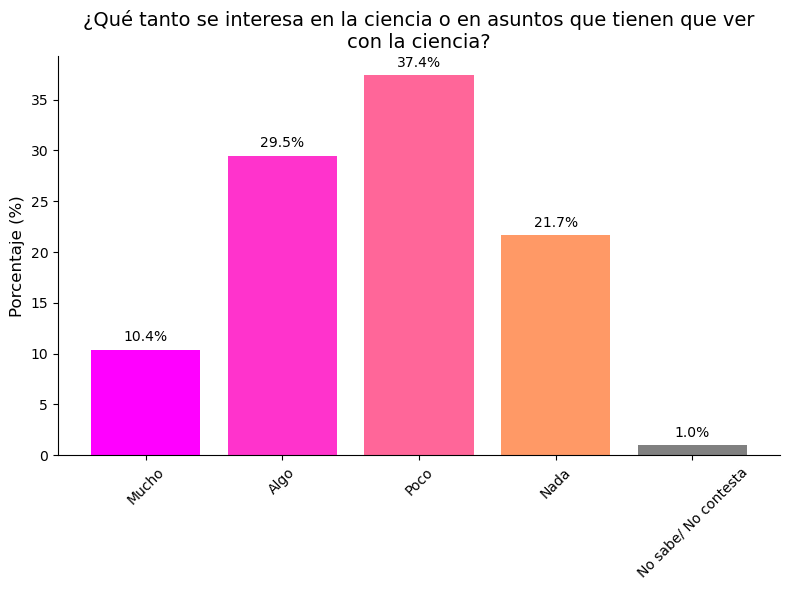

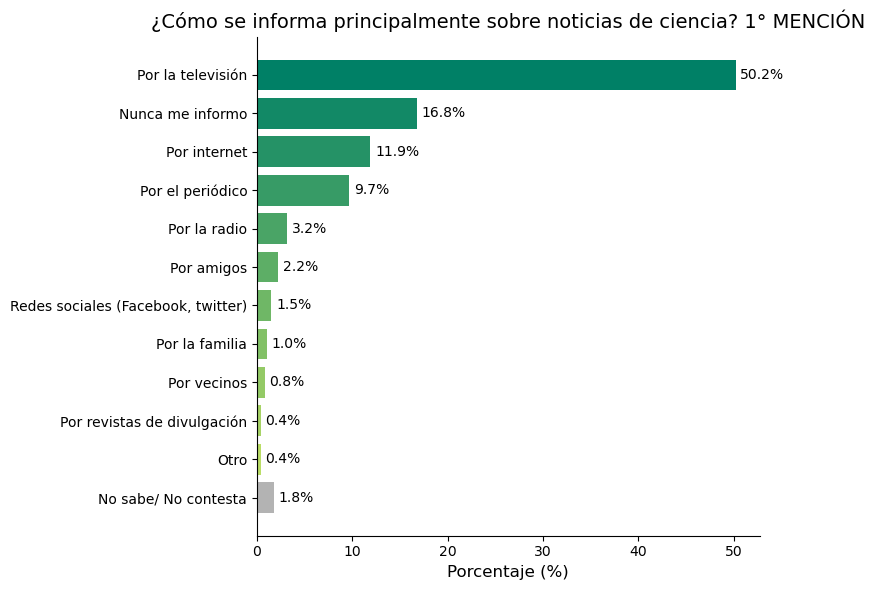

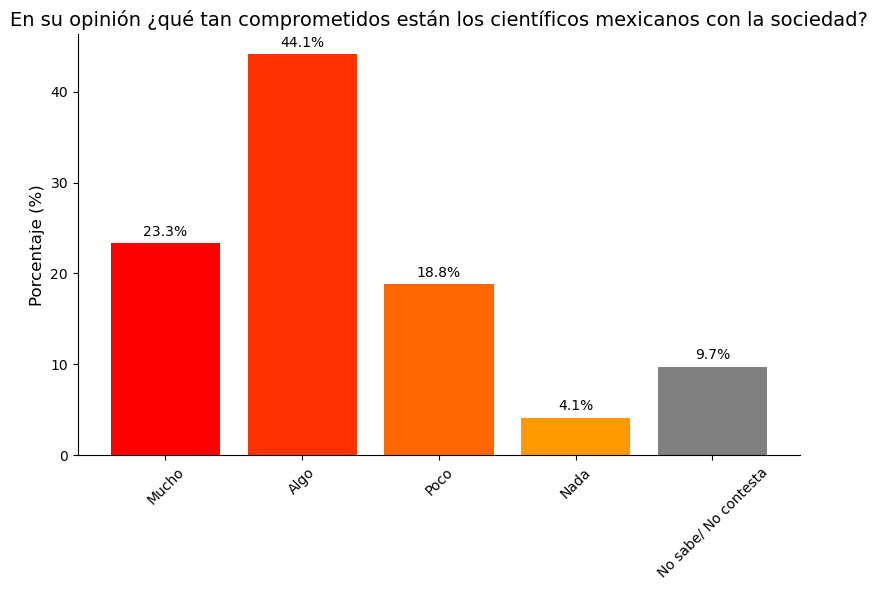

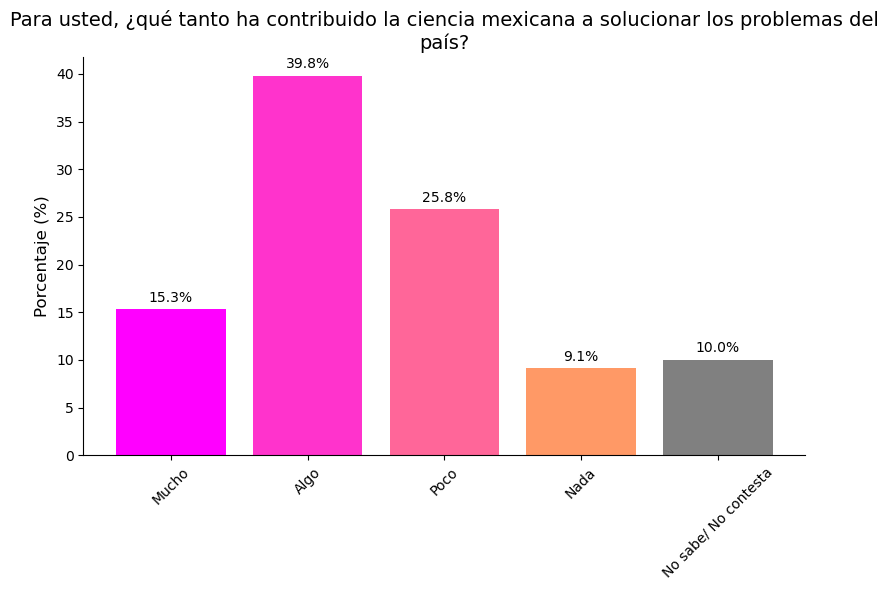

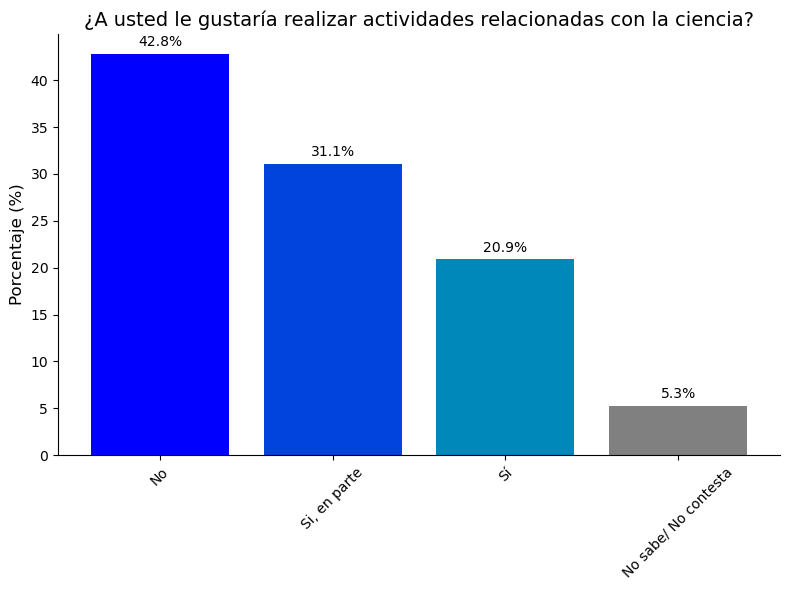

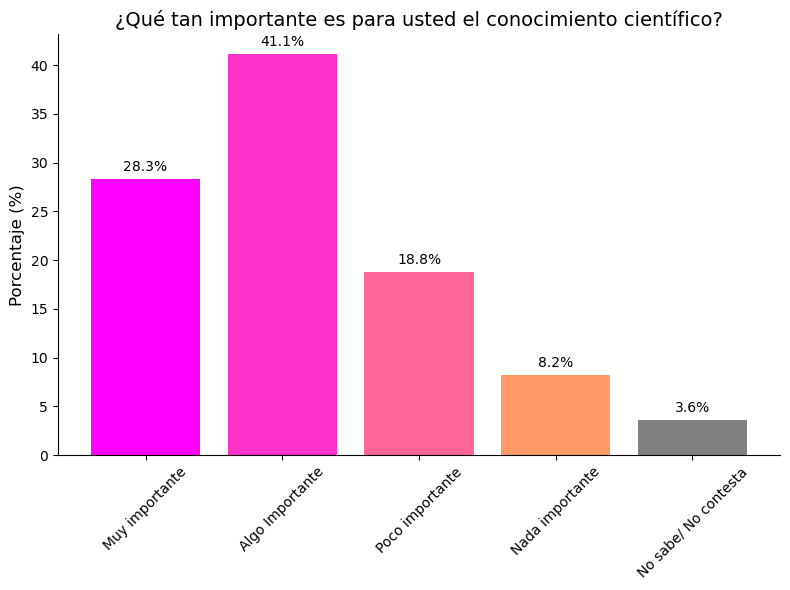

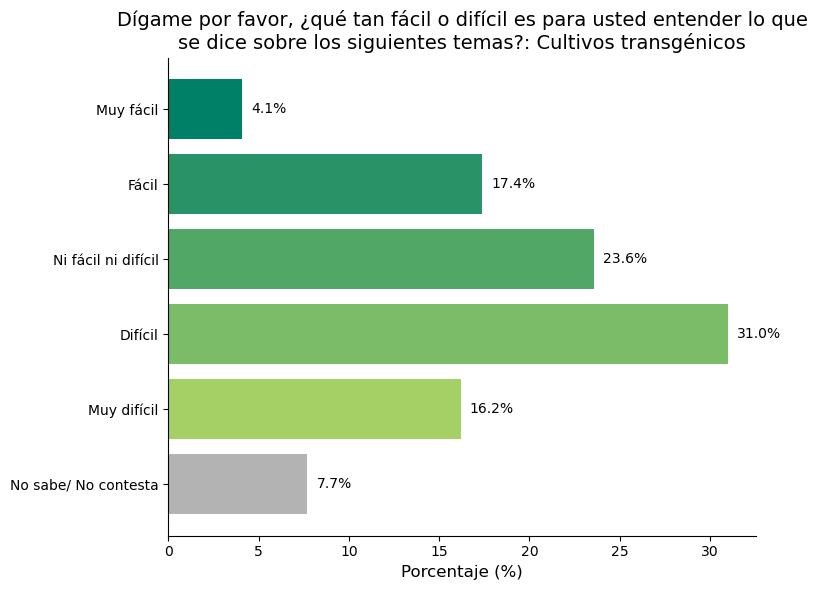

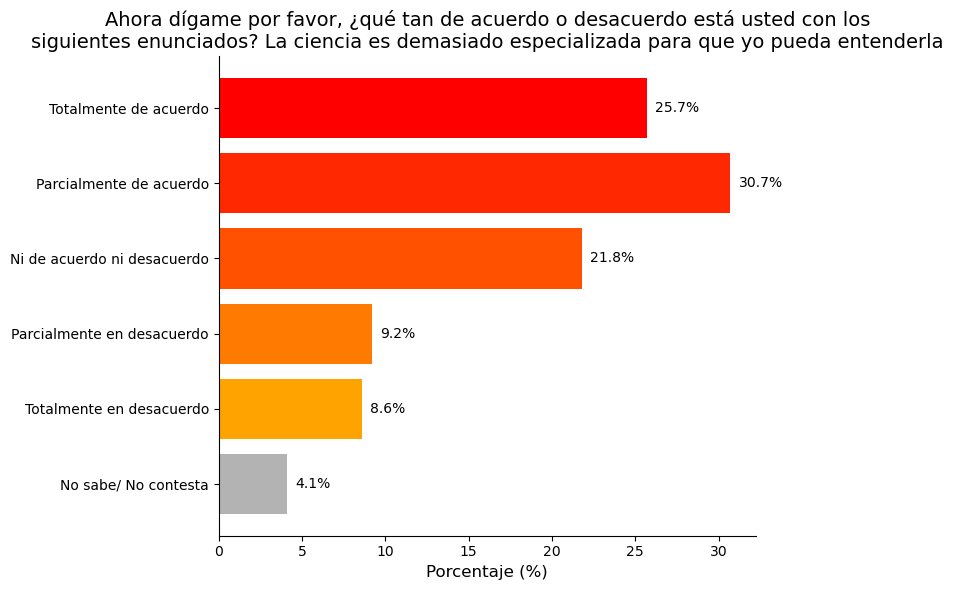

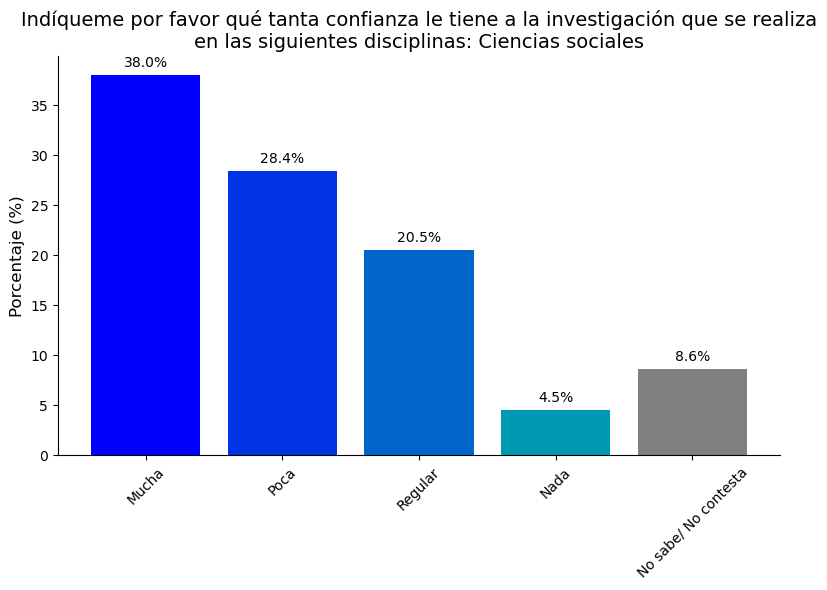

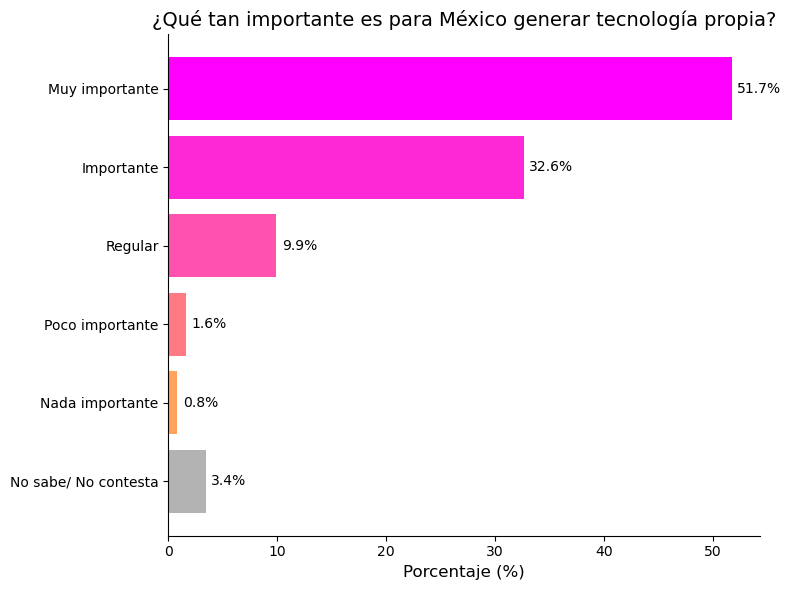

In [104]:
import numpy as np

import matplotlib.pyplot as plt

def split_text_by_words(text, n=14):
    """
    Splits a string into lines with a maximum of n words per line.

    Args:
        text (str): The input string to split.
        n (int): The maximum number of words per line.

    Returns:
        str: The formatted string with line breaks.
    """
    words = text.split()
    lines = [' '.join(words[i:i + n]) for i in range(0, len(words), n)]
    return '\n'.join(lines)

def create_plot(df, question, figsize=(6, 8)):
    """
    Creates a bar plot (horizontal if rows <= 6, vertical otherwise) of the survey data.

    Args:
        df (pd.DataFrame): DataFrame containing the data to plot.
        question (str): The survey question to use as the plot title.

    Returns:
        matplotlib.pyplot.figure: The matplotlib figure object.
    """
    # Determine plot type based on the number of rows
    if len(df) >= 6:
        # Horizontal bar plot
        fig, ax = plt.subplots(figsize=figsize)
        
        # Create a colormap where 'No sabe/ No contesta' is always gray

        colormaps = [plt.cm.summer, plt.cm.spring, plt.cm.winter, plt.cm.autumn]
        selected_colormap = np.random.choice(colormaps)
        colors = selected_colormap(np.linspace(0, 0.8, len(df)))

        if 'No sabe/ No contesta' in df.index:
            gray_index = list(df.index).index('No sabe/ No contesta')
            colors[gray_index] = [0.7, 0.7, 0.7, 1.0]  # RGBA for gray
        bars = ax.barh(df.index, df['%'], color=colors)

        # Add percentage labels to the bars
        for bar in bars:
            width = bar.get_width()
            label_position = width + 0.5  # Slightly to the right of the bar
            ax.text(label_position, bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%',
                    ha='left', va='center', fontsize=10)

        # Customize plot
        ax.set_xlabel('Porcentaje (%)', fontsize=12)
        ax.set_title(split_text_by_words(question), fontsize=14)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Invert the y-axis to show the first item at the top
        ax.invert_yaxis()
        plt.tight_layout()

    else:
        # Vertical bar plot
        fig, ax = plt.subplots(figsize=figsize)

        colormaps = [plt.cm.summer, plt.cm.spring, plt.cm.winter, plt.cm.autumn]
        selected_colormap = np.random.choice(colormaps)
        colors = selected_colormap(np.linspace(0, 0.8, len(df)))
        
        if 'No sabe/ No contesta' in df.index:
            gray_index = list(df.index).index('No sabe/ No contesta')
            colors[gray_index] = [0.5, 0.5, 0.5, 1.0]  # RGBA for gray

        bars = ax.bar(df.index, df['%'], color=colors)

        # Add percentage labels above the bars
        for bar in bars:
            height = bar.get_height()
            label_position = height + 0.5
            ax.text(bar.get_x() + bar.get_width()/2, label_position,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=10)

        # Customize plot
        ax.set_ylabel('Porcentaje (%)', fontsize=12)
        ax.set_title(split_text_by_words(question), fontsize=14)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()

    return fig

# Example usage:
for key, df in tmp_df_dict.items():
    question = tmp_sel_dict.get(key, 'Unknown Question')
    fig = create_plot(df, question, figsize=(8, 6))
    plt.show()  # Display each plot

In [122]:
from IPython.display import Markdown, display
from IPython.display import Image
from weasyprint import HTML

# title
query
# summary
answer_resumen.text
# recommendations
comments = {ky: tmp_sum_dict[ky]['answer'] for ky in tmp_sum_dict.keys()}
# plots
plots = {ky: create_plot(tmp_df_dict[ky], tmp_sel_dict[ky], figsize=(8, 6)) for ky in tmp_df_dict.keys()}

markdown_doc = f"# {query}\n\n"
markdown_doc += f"## Resumen\n\n{answer_resumen.text}\n\n"

# Add each comment followed by its plot
for ky in tmp_sum_dict.keys():
    markdown_doc += f"### {tmp_sel_dict[ky]}\n\n"
    markdown_doc += f"{comments[ky]}\n\n"
    # Save the plot as an image
    plot_path = f"plot_{ky}.png"
    # plots[ky].savefig(plot_path, format='png', bbox_inches='tight')
    plt.close(plots[ky])  # Close the plot to free up memory
    # Embed the image in the markdown
    markdown_doc += f"![Plot for {tmp_sel_dict[ky]}]({plot_path})\n\n"

# Display the markdown document
display(Markdown(markdown_doc))

import pypandoc

# If you already have your markdown string in `markdown_doc`:
output_pdf = "reporte.pdf"
pypandoc.convert_text(
    markdown_doc,
    to="pdf",
    format="md",
    outputfile=ruta_enc + output_pdf
)
print(f"Written {output_pdf}")


# qué es más importante para que la gente confíe en la ciencia?

## Resumen

El interés en la ciencia, la percepción de su contribución a la solución de problemas nacionales, la importancia que la gente le da al conocimiento científico, la facilidad para entender la información científica, la percepción de su accesibilidad, el fortalecimiento de la percepción positiva sobre la investigación en ciencias sociales, la generación de tecnología propia en México y el compromiso percibido de los científicos mexicanos con la sociedad son factores importantes para que la gente confíe en la ciencia.

Recomendamos que priorices la comunicación clara y accesible de la información científica, destacando la relevancia de la ciencia para resolver problemas nacionales y promoviendo la participación del público en actividades científicas. Deberías invertir en la divulgación científica a través de diversos medios, incluyendo la televisión, para llegar a un público más amplio. Además, es crucial fomentar una imagen positiva de la investigación en ciencias sociales y resaltar la capacidad de México para generar tecnología propia, lo que fortalecerá la confianza en la ciencia a nivel nacional. Finalmente, considera iniciativas que muestren el compromiso de los científicos con la sociedad, como proyectos de divulgación y participación ciudadana en la investigación.


### ¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?

El interés en la ciencia parece ser fundamental para construir la confianza pública en ella. Es probable que las personas con mayor interés en la ciencia estén más dispuestas a confiar en sus hallazgos y conclusiones.

![Plot for ¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?](plot_p11.png)

### ¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN

La gente que ve la televisión está más informada sobre ciencia, así que la ciencia debe invertir en ese medio para ganar confianza. Los científicos deben utilizar la televisión para comunicar mejor su investigación al público.

![Plot for ¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN](plot_p13_1.png)

### En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?

Aunque la tabla evalúa el compromiso percibido de los científicos mexicanos con la sociedad, este compromiso podría influir en la confianza pública en la ciencia. Si la gente percibe que los científicos están comprometidos con la sociedad, es más probable que confíen en su trabajo y en los resultados de sus investigaciones, aumentando así la credibilidad de la ciencia en general.

![Plot for En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?](plot_p33.png)

### Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?

La percepción de la contribución de la ciencia a la solución de problemas nacionales influye directamente en la confianza pública en la ciencia. Cuando la gente considera que la ciencia mexicana contribuye significativamente a resolver los problemas del país, es más probable que confíen en ella.

![Plot for Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?](plot_p34.png)

### ¿A usted le gustaría realizar actividades relacionadas con la ciencia?

Aunque esta tabla no pregunta directamente sobre la confianza en la ciencia, la disposición a participar en actividades científicas puede reflejar un nivel subyacente de confianza. Los resultados sugieren que aumentar la participación en actividades científicas podría ser una estrategia efectiva para fomentar la confianza en la ciencia, especialmente al convertir a aquellos que están indecisos en participantes activos.

![Plot for ¿A usted le gustaría realizar actividades relacionadas con la ciencia?](plot_p35.png)

### ¿Qué tan importante es para usted el conocimiento científico?

La importancia que la gente le da al conocimiento científico influye directamente en su confianza en la ciencia. Cuando una gran proporción de la población valora el conocimiento científico, es más probable que confíe en las conclusiones y avances que la ciencia ofrece.

![Plot for ¿Qué tan importante es para usted el conocimiento científico?](plot_p36.png)

### Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos

La facilidad para entender la información científica es un factor clave para la confianza. Si las personas encuentran difícil comprender temas como los cultivos transgénicos, es probable que desconfíen de la ciencia detrás de ellos. Por lo tanto, mejorar la comunicación científica y hacerla más accesible es fundamental para fortalecer la confianza pública en la ciencia.

![Plot for Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos](plot_p37_6.png)

### Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla

La confianza en la ciencia podría estar relacionada con la percepción de su accesibilidad. Si la gente siente que la ciencia es demasiado especializada y difícil de entender, es menos probable que confíe en ella. Por lo tanto, simplificar la ciencia y hacerla más accesible podría aumentar la confianza del público.

![Plot for Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla](plot_p45_1.png)

### Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales

Para generar confianza en la ciencia, es crucial fortalecer la percepción positiva sobre la investigación en ciencias sociales. Reducir la proporción de personas con poca o ninguna confianza, así como el porcentaje de quienes no saben o no contestan, mediante una mayor divulgación y transparencia en los procesos de investigación, podría ser fundamental para fomentar la credibilidad científica.

![Plot for Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales](plot_p50_4.png)

### ¿Qué tan importante es para México generar tecnología propia?

La generación de tecnología propia en México impulsa la confianza en la ciencia al demostrar la capacidad del país para innovar y resolver problemas locales. Al generar tecnología propia, se fomenta una cultura científica y se empodera a los investigadores mexicanos, lo que a su vez fortalece la credibilidad de la ciencia ante la población.

![Plot for ¿Qué tan importante es para México generar tecnología propia?](plot_p52.png)



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Written reporte.pdf


In [108]:
plots

{'p11': <Figure size 800x600 with 1 Axes>,
 'p13_1': <Figure size 800x600 with 1 Axes>,
 'p33': <Figure size 800x600 with 1 Axes>,
 'p34': <Figure size 800x600 with 1 Axes>,
 'p35': <Figure size 800x600 with 1 Axes>,
 'p36': <Figure size 800x600 with 1 Axes>,
 'p37_6': <Figure size 800x600 with 1 Axes>,
 'p45_1': <Figure size 800x600 with 1 Axes>,
 'p50_4': <Figure size 800x600 with 1 Axes>,
 'p52': <Figure size 800x600 with 1 Axes>}

In [134]:
# prompt para gráficos 

def create_prompt_plot(query, table_key, tmp_markdown_tables):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """
    tmp_tab_st = tmp_markdown_tables[table_key]

    prompt = f"""
    You are a very proficient python coder working on a survey research project, and an expert creative in data visualization and infographics.
    You are fully bilingual in English and Spanish, and can do its work in either language. 

    Your task is to take each of the following steps in sequence and make sure to follow up the results of each step with your work on the next one.

    1) analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    Based on your analysis of the table, you will create a plot that best represents the data in the table. Make the plot informative and visually appealing, but simple. 
    - think about the type of variable in the plot: it may be a scale, that contain qualifiers like 'mucho' or 'a lot' to 'nada' or 'nothing', or 'muy de acuerdo' or 'agree a lot' to 'nada de acuerdo' or 'not at all agree'.
    - also think about 'no sabe/ no contesta' or 'no answer/ does not know' option, and note that it will require special treatment in the plot.
    - think about the type of plot that best represents the data in the table, and how to make it visually appealing.
    
    Now, write a short description of the plot you are going to create, and the motivation behind your design.

    2) create a PLOT OBJECT in python that best represents the data in the table.

    The PLOT OBJECT should be a python code that generates the plot you designed in the first step.
    The plot should be a high-quality plot that is suitable for publication. It should be clear, easy to read, and visually appealing.
    The plot should include the following elements:
    - Use the viridis color map for every plot, unless for 'No sabe/ No contesta' should always be plotted in '#A9A9A9'.
    - Use horizontal bar plots and make sure that 'No sabe/ No contesta' is always at the bottom of the plot.
    - make sure to remove the top and right spines of the plot.
    - All elements of the plot should be in the same language as the query.

    The PLOT OBJECT should be the code to produce the plot of your design, using matplotlib, and it should retrun the plot object only. 
    Prioritize the correctness of the code over the aesthetics of the plot to make sure it runs correctly. Pay particular attention to the parameters required to assign colors, and betweeen the difference of c to color in hexbin and color as string names in matplotlib.

    This PLOT OBJECT returned should be the markdown version of the code chunck, so it can be either displayed or parsed for execution.

    3) review the code to make sure it works correctly, and revise it if necessary.

    4) You will only return a python dict called tmp_plot_res_dict[{table_key}], containaing the code as a string without markdown markers. 
    Do not initialize tmp_plot_res_dict because it will be initialized before execution of the code. 
    Make sure to add your reasoning ONLY to the code as comments, your answer should be only the code, ready to be parsed and executed. 
    Make sure to omit any markers like ```python or ```python, and do not include any other text in the answer.

    Try removing the triple quotes or placing them consistently to avoid string parsing errors. 
    Also consider returning only the code needed rather than the entire multiline string. 
    Make sure tmp_agg_out_lst is assigned valid Python code (without partial quotes or mismatched indentation) that can be executed directly.

    QUERY: {query}

    TABLE: {tmp_tab_st}
    """
    return prompt

# Example usage:
prompt = create_prompt_plot(query, 'p13_1', tmp_markdown_tables)


tmp_pmt_lst= [create_prompt_plot(query, ky_st, tmp_markdown_tables) for ky_st in tmp_markdown_tables.keys()]


# Define the configuration with lower temperature
model_config = types.GenerateContentConfig(
    temperature=0.0,
)

# Process each prompt individually
answers = {}
for i, prompt in enumerate(tmp_pmt_lst):
    print(f'generating answer for prompt {i+1}/{len(tmp_pmt_lst)}')
    key = list(tmp_markdown_tables.keys())[i] # Get the original key for this prompt
    answer = client.models.generate_content(
        model="gemini-2.0-flash",
        config=model_config,
        contents=prompt)
    answers[key] = answer # Store answer using the original key

tmp_ans_lst = [answers[ky].text.replace('tmp_plot_res_dict = {}\n', '') for ky in answers.keys()]
tmp_agg_ans_lst = [ans_st.strip("```python").replace("```", '\n').replace('python', '') for ans_st in tmp_ans_lst]
tmp_agg_out_lst = ''.join(tmp_agg_ans_lst)

import ast

# Validate and execute the generated code
def validate_and_execute(code_str):
    try:
        # Parse the code to ensure it is valid Python
        parsed_code = ast.parse(code_str)
        exec(compile(parsed_code, filename="<string>", mode="exec"))
    except Exception as e:
        print(f"Error in generated code: {e}")
        return None

validate_and_execute(tmp_agg_out_lst)

generating answer for prompt 1/9
generating answer for prompt 2/9
generating answer for prompt 3/9
generating answer for prompt 4/9
generating answer for prompt 5/9
generating answer for prompt 6/9
generating answer for prompt 7/9
generating answer for prompt 8/9
generating answer for prompt 9/9
Error in generated code: Unknown engine:  (valid options are dict_keys(['c', 'python', 'pyarrow', 'python-fwf']))


In [135]:
print(tmp_agg_out_lst)


# Define the data from the table
answers = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Define the plot function
def create_plot(answers, percentages):
    """
    Creates a horizontal bar plot of the survey data.

    Args:
        answers (list): List of answer options.
        percentages (list): List of percentages corresponding to each answer.

    Returns:
        matplotlib.pyplot.figure: The matplotlib figure object.
    """

    # Ensure the 'No sabe/ No contesta' is at the bottom
    if 'No sabe/ No contesta' in answers:
        no_answer_index = answers.index('No sabe/ No contesta')
        answers.append(answers.pop(no_answer_index))
        percentages.append(percentages.pop(no_answer_index))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1))  # viridis colormap
    bar_colors = 

In [ ]:
# Define the data from the table
answers = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Define the plot function
def create_plot(answers, percentages):
    """
    Creates a horizontal bar plot of the survey data.

    Args:
        answers (list): List of answer options.
        percentages (list): List of percentages corresponding to each answer.

    Returns:
        matplotlib.pyplot.figure: The matplotlib figure object.
    """

    # Ensure the 'No sabe/ No contesta' is at the bottom
    if 'No sabe/ No contesta' in answers:
        no_answer_index = answers.index('No sabe/ No contesta')
        answers.append(answers.pop(no_answer_index))
        percentages.append(percentages.pop(no_answer_index))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1))  # viridis colormap
    bar_colors = list(colors)
    bar_colors.append('#A9A9A9')  # Grey for 'No sabe/ No contesta'

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size for better readability

    # Create horizontal bars
    ax.barh(answers, percentages, color=bar_colors)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add labels and title
    ax.set_xlabel('Porcentaje (%)', fontsize=12)
    ax.set_title('¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?', fontsize=14)

    # Adjust x-axis limits
    ax.set_xlim(0, max(percentages) + 5)  # Add some padding to the right

    # Add percentage labels to the bars
    for i, v in enumerate(percentages):
        ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

    # Invert the y-axis to show the first item at the top
    ax.invert_yaxis()

    # Adjust layout to prevent labels from overlapping
    plt.tight_layout()

    return fig

# Create the plot object
fig = create_plot(answers, percentages)

# Convert the plot to a string representation
# # tmp_plot_res_dict['p11'] = '''
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib

# # Define the data from the table
# answers = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
# percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# # Define the plot function
# def create_plot(answers, percentages):
#     """
#     Creates a horizontal bar plot of the survey data.

#     Args:
#         answers (list): List of answer options.
#         percentages (list): List of percentages corresponding to each answer.

#     Returns:
#         matplotlib.pyplot.figure: The matplotlib figure object.
#     """

#     # Ensure the 'No sabe/ No contesta' is at the bottom
#     if 'No sabe/ No contesta' in answers:
#         no_answer_index = answers.index('No sabe/ No contesta')
#         answers.append(answers.pop(no_answer_index))
#         percentages.append(percentages.pop(no_answer_index))

#     # Define colors
#     colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1))  # viridis colormap
#     bar_colors = list(colors)
#     bar_colors.append('#A9A9A9')  # Grey for 'No sabe/ No contesta'

#     # Create the plot
#     fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size for better readability

#     # Create horizontal bars
#     ax.barh(answers, percentages, color=bar_colors)

#     # Remove top and right spines
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

#     # Add labels and title
#     ax.set_xlabel('Porcentaje (%)', fontsize=12)
#     ax.set_title('¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?', fontsize=14)

#     # Adjust x-axis limits
#     ax.set_xlim(0, max(percentages) + 5)  # Add some padding to the right

#     # Add percentage labels to the bars
#     for i, v in enumerate(percentages):
#         ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

#     # Invert the y-axis to show the first item at the top
#     ax.invert_yaxis()

#     # Adjust layout to prevent labels from overlapping
#     plt.tight_layout()

#     return fig

# # Create the plot object
# fig = create_plot(answers, percentages)
# '''
tmp_plot_res_dict['p11'] = """import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Define the data from the table
answers = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# Define the plot function
def create_plot(answers, percentages):
    # Ensure the 'No sabe/ No contesta' is at the bottom
    if 'No sabe/ No contesta' in answers:
        no_answer_index = answers.index('No sabe/ No contesta')
        answers.append(answers.pop(no_answer_index))
        percentages.append(percentages.pop(no_answer_index))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1))  # viridis colormap
    bar_colors = list(colors)
    bar_colors.append('#A9A9A9')  # Grey for 'No sabe/ No contesta'

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size for better readability

    # Create horizontal bars
    ax.barh(answers, percentages, color=bar_colors)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add labels and title
    ax.set_xlabel('Porcentaje (%)', fontsize=12)
    ax.set_title('¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?', fontsize=14)

    # Adjust x-axis limits
    ax.set_xlim(0, max(percentages) + 5)  # Add some padding to the right

    # Add percentage labels to the bars
    for i, v in enumerate(percentages):
        ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

    # Invert the y-axis to show the first item at the top
    ax.invert_yaxis()

    # Adjust layout to prevent labels from overlapping
    plt.tight_layout()

    return fig

# Create the plot object
fig = create_plot(answers, percentages)
"""

# Analyzing the table:
# The table shows the percentage of people who get their science news from different sources.
# The variable is categorical, with options like "Television", "Internet", "Newspaper", etc.
# "No sabe/ No contesta" is present and needs special handling.
# A horizontal bar plot is suitable for visualizing this data, with bars representing each source and their length representing the percentage.
# "No sabe/ No contesta" will be placed at the bottom and colored in grey.

# Creating the plot object:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io

# Data provided in the prompt
data = {
    '¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN': [
        'Por la televisión',
        'Nunca me informo',
        'Por internet',
        'Por el periódico',
        'Por la radio',
        'Por amigos',
        'Redes sociales (Facebook, twitter)',
        'Por la familia',
        'No sabe/ No contesta',
        'Por vecinos',
        'Por revistas de divulgación',
        'Otro'
    ],
    '%': [50.2, 16.8, 11.9, 9.7, 3.2, 2.2, 1.5, 1.0, 1.8, 0.8, 0.4, 0.4]
}

df = pd.DataFrame(data)

# Ensure the percentages are numeric
df['%'] = pd.to_numeric(df['%'])

# Move "No sabe/ No contesta" to the end
no_sabe = df[df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'] == 'No sabe/ No contesta']
df = df[df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define colors: viridis for the sources, grey for "No sabe/ No contesta"
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df) - 1)).tolist()
colors.append('#A9A9A9')  # Grey for "No sabe/ No contesta"

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar plot
ax.barh(df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'], df['%'], color=colors)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add labels and title
ax.set_xlabel('Porcentaje', fontsize=12)
ax.set_title('¿Cómo se informa principalmente sobre noticias de ciencia?', fontsize=14)

# Invert the y-axis to have the first item at the top
ax.invert_yaxis()

# Add percentage labels to the bars
for i, v in enumerate(df['%']):
    ax.text(v + 0.5, i, str(v) + '%', color='black', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
tmp_plot_res_dict['p13_1'] = """
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io

# Data provided in the prompt
data = {
    '¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN': [
        'Por la televisión',
        'Nunca me informo',
        'Por internet',
        'Por el periódico',
        'Por la radio',
        'Por amigos',
        'Redes sociales (Facebook, twitter)',
        'Por la familia',
        'No sabe/ No contesta',
        'Por vecinos',
        'Por revistas de divulgación',
        'Otro'
    ],
    '%': [50.2, 16.8, 11.9, 9.7, 3.2, 2.2, 1.5, 1.0, 1.8, 0.8, 0.4, 0.4]
}

df = pd.DataFrame(data)

# Ensure the percentages are numeric
df['%'] = pd.to_numeric(df['%'])

# Move "No sabe/ No contesta" to the end
no_sabe = df[df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'] == 'No sabe/ No contesta']
df = df[df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define colors: viridis for the sources, grey for "No sabe/ No contesta"
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df) - 1)).tolist()
colors.append('#A9A9A9')  # Grey for "No sabe/ No contesta"

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar plot
ax.barh(df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'], df['%'], color=colors)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add labels and title
ax.set_xlabel('Porcentaje', fontsize=12)
ax.set_title('¿Cómo se informa principalmente sobre noticias de ciencia?', fontsize=14)

# Invert the y-axis to have the first item at the top
ax.invert_yaxis()

# Add percentage labels to the bars
for i, v in enumerate(df['%']):
    ax.text(v + 0.5, i, str(v) + '%', color='black', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

plt.show()
"""

# Analyzing the table:
# The question is about the level of commitment of Mexican scientists to society.
# The answers are on a scale from "Nada" (Nothing) to "Mucho" (A lot), with a "No sabe/ No contesta" (Don't know/No answer) option.
# A horizontal bar plot is suitable for this data, as it allows for easy comparison of the percentages for each level of commitment.
# The "No sabe/ No contesta" option will be placed at the bottom of the plot and colored in grey.

# Creating the plot object:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from the table
data = {'Compromiso': ['Algo', 'Mucho', 'Poco', 'Nada', 'No sabe/ No contesta'],
        'Porcentaje': [44.1, 23.3, 18.8, 4.1, 9.7]}
df = pd.DataFrame(data)

# Sort the DataFrame to put 'No sabe/ No contesta' at the bottom
df = df.sort_values(by='Compromiso', key=lambda x: x == 'No sabe/ No contesta')

# Colors: viridis for the scale, grey for 'No sabe/ No contesta'
colors = ['#A9A9A9' if x == 'No sabe/ No contesta' else plt.cm.viridis(i/float(len(df)-1)) for i, x in enumerate(df['Compromiso'])]

# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df['Compromiso'], df['Porcentaje'], color=colors)

# Removing top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adding labels and title
ax.set_xlabel('Porcentaje', fontsize=12)
ax.set_ylabel('Compromiso', fontsize=12)
ax.set_title('¿Qué tan comprometidos están los científicos mexicanos con la sociedad?', fontsize=14)

# Adding percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    label_position = width + 0.5  # Slightly to the right of the bar
    ax.text(label_position, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            ha='left', va='center', fontsize=10)

# Adjusting layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
tmp_plot_res_dict['p33'] = """
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from the table
data = {'Compromiso': ['Algo', 'Mucho', 'Poco', 'Nada', 'No sabe/ No contesta'],
        'Porcentaje': [44.1, 23.3, 18.8, 4.1, 9.7]}
df = pd.DataFrame(data)

# Sort the DataFrame to put 'No sabe/ No contesta' at the bottom
df = df.sort_values(by='Compromiso', key=lambda x: x == 'No sabe/ No contesta')

# Colors: viridis for the scale, grey for 'No sabe/ No contesta'
colors = ['#A9A9A9' if x == 'No sabe/ No contesta' else plt.cm.viridis(i/float(len(df)-1)) for i, x in enumerate(df['Compromiso'])]

# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df['Compromiso'], df['Porcentaje'], color=colors)

# Removing top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adding labels and title
ax.set_xlabel('Porcentaje', fontsize=12)
ax.set_ylabel('Compromiso', fontsize=12)
ax.set_title('¿Qué tan comprometidos están los científicos mexicanos con la sociedad?', fontsize=14)

# Adding percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    label_position = width + 0.5  # Slightly to the right of the bar
    ax.text(label_position, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            ha='left', va='center', fontsize=10)

# Adjusting layout to prevent labels from being cut off
plt.tight_layout()

plt.show()
"""

# Define the dictionary to store the plot code

# Analyze the table and determine the best plot type
# The data represents the distribution of opinions on the contribution of Mexican science to solving the country's problems.
# A horizontal bar plot is suitable for visualizing this type of data, as it allows for easy comparison of the percentages for each category.
# The 'No sabe/ No contesta' category will be placed at the bottom of the plot and colored in grey.

# Create the plot object in Python
tmp_agg_out_lst = """
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Data from the table
categories = ['Nada', 'Poco', 'Algo', 'Mucho', 'No sabe/ No contesta']
percentages = [9.1, 25.8, 39.8, 15.3, 10.0]

# Sort categories and percentages, placing 'No sabe/ No contesta' at the end
categories, percentages = zip(*sorted(zip(categories, percentages), key=lambda x: x[0] != 'No sabe/ No contesta'))
categories = list(categories)
percentages = list(percentages)

# Colors for the bars, using viridis colormap and grey for 'No sabe/ No contesta'
colors = matplotlib.colormaps['viridis'](np.linspace(0, 0.7, len(categories)-1)).tolist()
colors.append('#A9A9A9') # Grey color for 'No sabe/ No contesta'

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(categories, percentages, color=colors)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 1 # Position the label slightly to the right of the bar
    ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
            ha='left', va='center', color='black')

# Set plot title and labels
ax.set_xlabel('Porcentaje')
ax.set_title('¿Qué tanto ha contribuido la ciencia mexicana a solucionar los problemas del país?')

# Invert the y-axis to have 'No sabe/ No contesta' at the bottom
ax.invert_yaxis()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
plt
"""

# Store the plot code in the dictionary
tmp_plot_res_dict['p34'] = tmp_agg_out_lst

# Analyze the table and determine the best plot type.
# The data represents the importance of scientific knowledge, which is an ordinal scale.
# A horizontal bar plot is suitable for visualizing the percentages for each category.
# The 'No sabe/ No contesta' category will be placed at the bottom and colored differently.

# Description of the plot:
# A horizontal bar plot showing the percentage of people who selected each answer option.
# The bars are ordered from 'Muy importante' to 'Nada importante', with 'No sabe/ No contesta' at the bottom.
# The bars are colored using the viridis colormap, except for 'No sabe/ No contesta', which is gray.
# The plot includes labels for each bar and the percentage values.
# The top and right spines are removed for a cleaner look.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from the table
data = {
    'Respuesta': ['Algo Importante', 'Muy importante', 'Poco importante', 'Nada importante', 'No sabe/ No contesta'],
    'Porcentaje': [41.1, 28.3, 18.8, 8.2, 3.6]
}
df = pd.DataFrame(data)

# Order the DataFrame as desired
order = ['Muy importante', 'Algo Importante', 'Poco importante', 'Nada importante', 'No sabe/ No contesta']
df['Respuesta'] = pd.Categorical(df['Respuesta'], categories=order, ordered=True)
df = df.sort_values('Respuesta')

# Colors
colors = plt.cm.viridis(np.linspace(0, 1, len(df) - 1))
color_nsnc = '#A9A9A9'  # Gray color for 'No sabe/ No contesta'
colors = np.append(colors, color_nsnc)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(df['Respuesta'], df['Porcentaje'], color=colors)

# Add percentage labels
for i, v in enumerate(df['Porcentaje']):
    ax.text(v + 1, i, str(v) + '%', color='black', va='center')

# Customize plot
ax.set_xlabel('Porcentaje')
ax.set_title('¿Qué es más importante para que la gente confíe en la ciencia?')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Return the plot object
tmp_plot_res_dict['p36'] = """
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from the table
data = {
    'Respuesta': ['Algo Importante', 'Muy importante', 'Poco importante', 'Nada importante', 'No sabe/ No contesta'],
    'Porcentaje': [41.1, 28.3, 18.8, 8.2, 3.6]
}
df = pd.DataFrame(data)

# Order the DataFrame as desired
order = ['Muy importante', 'Algo Importante', 'Poco importante', 'Nada importante', 'No sabe/ No contesta']
df['Respuesta'] = pd.Categorical(df['Respuesta'], categories=order, ordered=True)
df = df.sort_values('Respuesta')

# Colors
colors = plt.cm.viridis(np.linspace(0, 1, len(df) - 1))
color_nsnc = '#A9A9A9'  # Gray color for 'No sabe/ No contesta'
colors = np.append(colors, color_nsnc)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(df['Respuesta'], df['Porcentaje'], color=colors)

# Add percentage labels
for i, v in enumerate(df['Porcentaje']):
    ax.text(v + 1, i, str(v) + '%', color='black', va='center')

# Customize plot
ax.set_xlabel('Porcentaje')
ax.set_title('¿Qué es más importante para que la gente confíe en la ciencia?')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
"""

# Define the plot description
# We will create a horizontal bar plot to represent the survey data.
# The x-axis will represent the percentage of respondents, and the y-axis will represent the answer options.
# The 'No sabe/ No contesta' option will be placed at the bottom of the plot and colored in grey.
# The other options will be colored using the viridis colormap.
# The plot will have a clean and simple design, with the top and right spines removed.
# All elements of the plot will be in Spanish.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io

# Define the data from the table
data = """
| Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos   |    % |
|:--------------------------------------------------------------------------------------------------------------------------------------|-----:|
| Difícil                                                                                                                               | 31.0 |
| Ni fácil ni difícil                                                                                                                   | 23.6 |
| Fácil                                                                                                                                 | 17.4 |
| Muy difícil                                                                                                                           | 16.2 |
| Muy fácil                                                                                                                             |  4.1 |
| No sabe/ No contesta                                                                                                                  |  7.7 |
"""

# Read the data into a pandas DataFrame
df = pd.read_csv(io.StringIO(data), sep='|', engine='', skipinitialspace=True).iloc[1:]
df.columns = [col.strip() for col in df.columns]
df = df.rename(columns={df.columns[1]: 'Percentage', df.columns[0]: 'Answer'})
df['Percentage'] = df['Percentage'].str.strip().astype(float)
df['Answer'] = df['Answer'].str.strip()

# Reorder the DataFrame to put 'No sabe/ No contesta' at the bottom
no_sabe = df[df['Answer'] == 'No sabe/ No contesta']
df = df[df['Answer'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define the colors for the bars
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df) - 1)) # Use viridis colormap
color_list = list(colors)
color_list.append('#A9A9A9') # Grey for 'No sabe/ No contesta'
colors = color_list

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df['Answer'], df['Percentage'], color=colors)

# Set the title and labels
ax.set_xlabel('Porcentaje (%)')
ax.set_title('¿Qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos')

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Invert the y-axis to have the first item at the top
ax.invert_yaxis()

# Add percentage labels to the bars
for i, v in enumerate(df['Percentage']):
    ax.text(v + 1, i, str(v) + '%', color='black', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
tmp_plot_res_dict['p37_6'] = """
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io

# Define the data from the table
data = \"\"\"
| Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos   |    % |
|:--------------------------------------------------------------------------------------------------------------------------------------|-----:|
| Difícil                                                                                                                               | 31.0 |
| Ni fácil ni difícil                                                                                                                   | 23.6 |
| Fácil                                                                                                                                 | 17.4 |
| Muy difícil                                                                                                                           | 16.2 |
| Muy fácil                                                                                                                             |  4.1 |
| No sabe/ No contesta                                                                                                                  |  7.7 |
\"\"\"

# Read the data into a pandas DataFrame
df = pd.read_csv(io.StringIO(data), sep='|', engine='', skipinitialspace=True).iloc[1:]
df.columns = [col.strip() for col in df.columns]
df = df.rename(columns={df.columns[1]: 'Percentage', df.columns[0]: 'Answer'})
df['Percentage'] = df['Percentage'].str.strip().astype(float)
df['Answer'] = df['Answer'].str.strip()

# Reorder the DataFrame to put 'No sabe/ No contesta' at the bottom
no_sabe = df[df['Answer'] == 'No sabe/ No contesta']
df = df[df['Answer'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define the colors for the bars
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df) - 1)) # Use viridis colormap
color_list = list(colors)
color_list.append('#A9A9A9') # Grey for 'No sabe/ No contesta'
colors = color_list

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df['Answer'], df['Percentage'], color=colors)

# Set the title and labels
ax.set_xlabel('Porcentaje (%)')
ax.set_title('¿Qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos')

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Invert the y-axis to have the first item at the top
ax.invert_yaxis()

# Add percentage labels to the bars
for i, v in enumerate(df['Percentage']):
    ax.text(v + 1, i, str(v) + '%', color='black', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
plt
"""

# This code generates a horizontal bar plot to visualize survey responses.
# The plot displays the percentage of respondents for each agreement level,
# with 'No sabe/ No contesta' at the bottom and a grey color.
# Viridis colormap is used for the other categories.

import matplotlib.pyplot as plt
import numpy as np

# Data from the table
categories = ['Parcialmente de acuerdo', 'Totalmente de acuerdo', 'Ni de acuerdo ni desacuerdo',
              'Parcialmente en desacuerdo', 'Totalmente en desacuerdo', 'No sabe/ No contesta']
percentages = [30.7, 25.7, 21.8, 9.2, 8.6, 4.1]

# Define colors, using viridis for agreement levels and grey for 'No sabe/ No contesta'
colors = plt.cm.viridis(np.linspace(0, 0.7, len(categories) - 1)).tolist() # Use a subset of viridis
colors.append('#A9A9A9')  # Grey color for 'No sabe/ No contesta'

# Reorder categories and percentages to put 'No sabe/ No contesta' at the bottom
categories = categories[:-1] + [categories[-1]]
percentages = percentages[:-1] + [percentages[-1]]
colors = colors[:-1] + [colors[-1]]

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(categories, percentages, color=colors)

# Add labels and title
ax.set_xlabel('Porcentaje (%)')
ax.set_title('¿Qué tan de acuerdo o desacuerdo está usted con la siguiente afirmación: \nLa ciencia es demasiado especializada para que yo pueda entenderla?', fontsize=12)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             '{:.1f}%'.format(width),
             ha='left', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
tmp_plot_res_dict['p45_1'] = """
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
categories = ['Parcialmente de acuerdo', 'Totalmente de acuerdo', 'Ni de acuerdo ni desacuerdo',
              'Parcialmente en desacuerdo', 'Totalmente en desacuerdo', 'No sabe/ No contesta']
percentages = [30.7, 25.7, 21.8, 9.2, 8.6, 4.1]

# Define colors, using viridis for agreement levels and grey for 'No sabe/ No contesta'
colors = plt.cm.viridis(np.linspace(0, 0.7, len(categories) - 1)).tolist() # Use a subset of viridis
colors.append('#A9A9A9')  # Grey color for 'No sabe/ No contesta'

# Reorder categories and percentages to put 'No sabe/ No contesta' at the bottom
categories = categories[:-1] + [categories[-1]]
percentages = percentages[:-1] + [percentages[-1]]
colors = colors[:-1] + [colors[-1]]

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(categories, percentages, color=colors)

# Add labels and title
ax.set_xlabel('Porcentaje (%)')
ax.set_title('¿Qué tan de acuerdo o desacuerdo está usted con la siguiente afirmación: \nLa ciencia es demasiado especializada para que yo pueda entenderla?', fontsize=12)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             '{:.1f}%'.format(width),
             ha='left', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

plt
"""

# Define the plot object as a string
tmp_plot_res_dict['p50_4'] = """
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Data from the table
categories = ['Mucha', 'Poca', 'Regular', 'Nada', 'No sabe/ No contesta']
percentage = [38.0, 28.4, 20.5, 4.5, 8.6]

# Define colors, using viridis colormap and grey for 'No sabe/ No contesta'
colors = plt.cm.viridis(np.linspace(0, 0.8, len(categories)-1)) # Exclude 'No sabe/ No contesta' from the colormap range
colors = np.append(colors, '#A9A9A9') # Append grey color for 'No sabe/ No contesta'

# Sort categories and percentages, placing 'No sabe/ No contesta' at the end
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Create horizontal bar plot
bars = ax.barh(categories, percentage, color=colors)

# Add percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    label_x_position = width + 0.5  # Position the label slightly to the right of the bar
    ax.text(label_x_position, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            ha='left', va='center')

# Customize the plot
ax.set_xlabel('Porcentaje')
ax.set_title('Confianza en la investigación en Ciencias Sociales')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Invert the y-axis to have categories in the correct order
ax.invert_yaxis()

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Return the plot object
plt
"""

# Define the data from the table
question = "¿Qué tan importante es para México generar tecnología propia?"
answers = ["Muy importante", "Importante", "Regular", "Poco importante", "Nada importante", "No sabe/ No contesta"]
percentages = [51.7, 32.6, 9.9, 1.6, 0.8, 3.4]

# Sort the data so that "No sabe/ No contesta" is at the bottom
# Create a list of tuples (percentage, answer)
data = list(zip(percentages, answers))
# Move "No sabe/ No contesta" to the end
no_answer = next((item for item in data if item[1] == "No sabe/ No contesta"), None)
if no_answer:
    data.remove(no_answer)
    data.append(no_answer)

# Separate the sorted data back into lists
percentages, answers = zip(*data)

# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Define the plot
def create_plot(question, answers, percentages):
    """
    Creates a horizontal bar plot of the survey data.

    Args:
        question (str): The survey question.
        answers (list): A list of answer options.
        percentages (list): A list of percentages corresponding to each answer.

    Returns:
        matplotlib.pyplot.figure: The plot object.
    """

    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(10, 6))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1)) # Use viridis colormap
    no_answer_color = '#A9A9A9'  # Grey color for "No sabe/ No contesta"
    bar_colors = list(colors)
    if "No sabe/ No contesta" in answers:
        bar_colors.insert(answers.index("No sabe/ No contesta"), no_answer_color)
    
    # Create the horizontal bar plot
    ax.barh(answers, percentages, color=bar_colors)

    # Customize the plot
    ax.set_title(question, fontsize=14)
    ax.set_xlabel("Porcentaje (%)", fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add percentage labels to the bars
    for i, v in enumerate(percentages):
        ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

    # Adjust layout to prevent labels from being cut off
    plt.tight_layout()

    return fig

# Generate the plot
plot = create_plot(question, answers, percentages)

# Store the plot object in the dictionary
tmp_plot_res_dict['p52'] = """
import matplotlib.pyplot as plt
import numpy as np

# Define the plot
def create_plot(question, answers, percentages):
    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(10, 6))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1)) # Use viridis colormap
    no_answer_color = '#A9A9A9'  # Grey color for "No sabe/ No contesta"
    bar_colors = list(colors)
    if "No sabe/ No contesta" in answers:
        bar_colors.insert(answers.index("No sabe/ No contesta"), no_answer_color)
    
    # Create the horizontal bar plot
    ax.barh(answers, percentages, color=bar_colors)

    # Customize the plot
    ax.set_title(question, fontsize=14)
    ax.set_xlabel("Porcentaje (%)", fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add percentage labels to the bars
    for i, v in enumerate(percentages):
        ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

    # Adjust layout to prevent labels from being cut off
    plt.tight_layout()

    return fig

# Data
question = "¿Qué tan importante es para México generar tecnología propia?"
answers = ["Muy importante", "Importante", "Regular", "Poco importante", "Nada importante", "No sabe/ No contesta"]
percentages = [51.7, 32.6, 9.9, 1.6, 0.8, 3.4]

# Sort the data so that "No sabe/ No contesta" is at the bottom
# Create a list of tuples (percentage, answer)
data = list(zip(percentages, answers))
# Move "No sabe/ No contesta" to the end
no_answer = next((item for item in data if item[1] == "No sabe/ No contesta"), None)
if no_answer:
    data.remove(no_answer)
    data.append(no_answer)

# Separate the sorted data back into lists
percentages, answers = zip(*data)

plot = create_plot(question, answers, percentages)
"""

In [129]:
# validation of the generated code



# # Example usage
# tmp_agg_out_lst = """
# import matplotlib.pyplot as plt
# import numpy as np

# # Define the data from the table
# categories = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
# percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# # Define colors using the viridis colormap, ensuring 'No sabe/ No contesta' is gray
# colors = plt.cm.viridis(np.linspace(0, 1, len(categories) - 1)).tolist()
# colors.append('#A9A9A9')  # Append dark gray color for 'No sabe/ No contesta'

# # Create the horizontal bar plot
# fig, ax = plt.subplots(figsize=(8, 6))
# bars = ax.barh(categories, percentages, color=colors)

# # Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# # Add percentage labels to the bars
# for bar in bars:
#     width = bar.get_width()
#     label_position = width + 1  # Position the label slightly to the right of the bar
#     ax.text(label_position, bar.get_y() + bar.get_height() / 2,
#             f'{width:.1f}%', ha='left', va='center')

# # Invert the y-axis to have 'No sabe/ No contesta' at the bottom
# ax.invert_yaxis()

# # Set the x-axis label
# ax.set_xlabel('Porcentaje', fontsize=12)

# # Set the plot title
# ax.set_title('¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?', fontsize=14)

# # Adjust layout to prevent labels from being cut off
# plt.tight_layout()
# plt.show()
# """

# Validate and execute the code


Error in generated code: Unknown engine:  (valid options are dict_keys(['c', 'python', 'pyarrow', 'python-fwf']))


In [ ]:
import pandas as pd
import io

# Corrected code for reading the data into a pandas DataFrame
df = pd.read_csv(io.StringIO(data), sep='|', engine='python', skipinitialspace=True)

In [122]:
tmp_pmt_lst= [create_prompt_plot(query, ky_st, tmp_markdown_tables) for ky_st in tmp_markdown_tables.keys()]

# Process each prompt individually
answers = {}
for i, prompt in enumerate(tmp_pmt_lst):
    print(f'generating answer for prompt {i+1}/{len(tmp_pmt_lst)}')
    key = list(tmp_markdown_tables.keys())[i] # Get the original key for this prompt
    answer = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt)
    answers[key] = answer # Store answer using the original key

tmp_ans_lst = [answers[ky].text.replace('tmp_plot_res_dict = {}\n', '') for ky in answers.keys()]
tmp_agg_ans_lst = [ans_st.strip("```python").replace("```", '\n').replace('python', '') for ans_st in tmp_ans_lst]
tmp_agg_out_lst = ''.join(tmp_agg_ans_lst)

tmp_agg_out_lst

# # Display the query and all answers
# display(Markdown(f"**Query:** {query}"))
# for key, answer in answers.items():
#     # Use tmp_sel_dict (defined in cell 63) to get the question text
#     display(Markdown(f"--- \n**Analysis for question {key} ({tmp_sel_dict.get(key, 'Unknown Question')}):**"))
#     display(Markdown(answer.text))

generating answer for prompt 1/9
generating answer for prompt 2/9
generating answer for prompt 3/9
generating answer for prompt 4/9
generating answer for prompt 5/9
generating answer for prompt 6/9
generating answer for prompt 7/9
generating answer for prompt 8/9
generating answer for prompt 9/9


In [124]:
tmp_ans_lst = [answers[ky].text.replace('tmp_plot_res_dict = {}\n', '') for ky in answers.keys()]
tmp_agg_ans_lst = [ans_st.strip("```python").replace("```", '\n').replace('python', '') for ans_st in tmp_ans_lst]
tmp_agg_out_lst = ''.join(tmp_agg_ans_lst)

tmp_agg_out_lst

'\n# Define the data from the table\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# Define the data from the table\ncategories = [\'Poco\', \'Algo\', \'Nada\', \'Mucho\', \'No sabe/ No contesta\']\npercentages = [37.4, 29.5, 21.7, 10.4, 1.0]\n\n# Define colors using the viridis colormap, ensuring \'No sabe/ No contesta\' is gray\ncolors = plt.cm.viridis(np.linspace(0, 1, len(categories) - 1))\ncolors = np.append(colors, \'darkgray\')  # Append gray color for \'No sabe/ No contesta\'\ncolors = colors[[3,1,2,0,4]]\n\n# Create the horizontal bar plot\nfig, ax = plt.subplots(figsize=(8, 6))\n\n# Create horizontal bars\nbars = ax.barh(categories, percentages, color=colors)\n\n# Remove top and right spines\nax.spines[\'top\'].set_visible(False)\nax.spines[\'right\'].set_visible(False)\n\n# Add percentage labels to the bars\nfor bar in bars:\n    width = bar.get_width()\n    label_position = width + 1  # Position the label slightly to the right of the bar\n    ax.text(label_position

ValueError: could not convert string to float: 'darkgray'

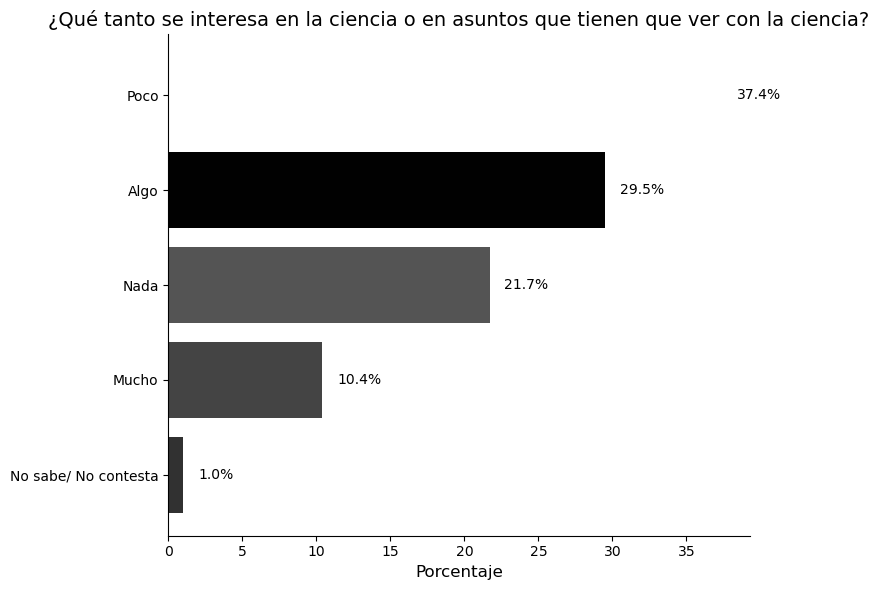

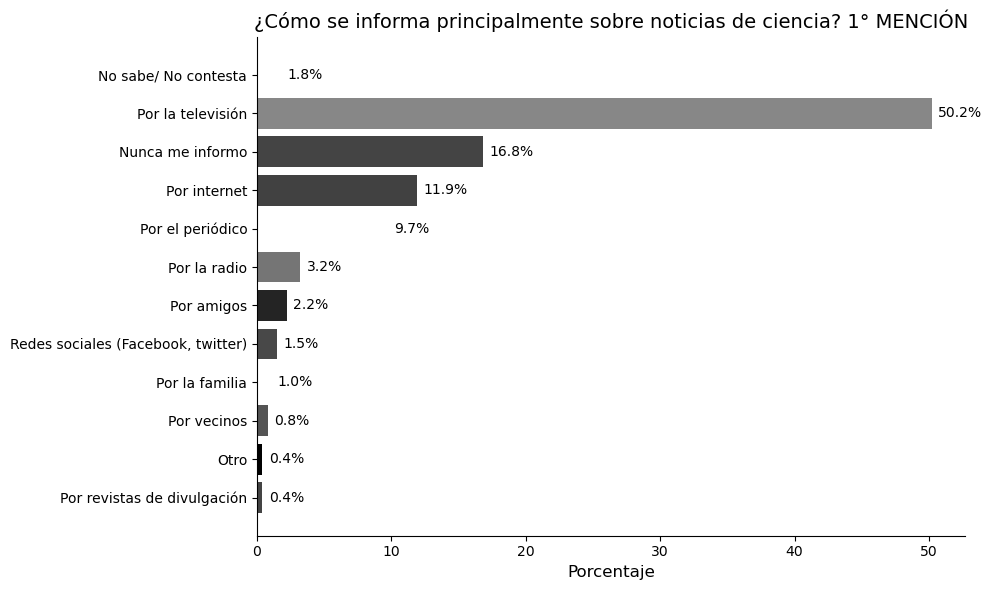

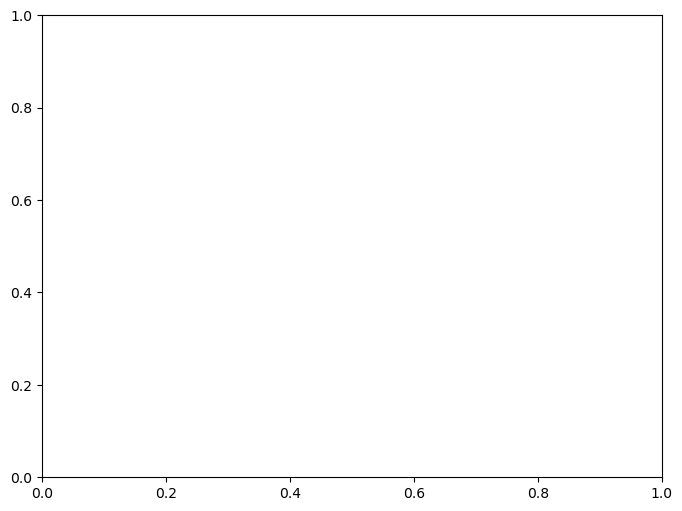

In [125]:
tmp_plot_res_dict = {}

tmp_plot_res_dict= exec(tmp_agg_out_lst)

for ky in tmp_plot_res_dict.keys():
    print(f"---\n{ky}:\n")
    print(tmp_plot_res_dict[ky]['description'])
    print("\n---\n")
    exec(tmp_plot_res_dict[ky]['plot'])

In [94]:

tmp_ans_lst = [answers[ky].text.replace('tmp_plot_res_dict = {}\n', '') for ky in answers.keys()]
tmp_agg_ans_lst = [ans_st.strip("```python").replace("```", '\n').replace('python', '') for ans_st in tmp_ans_lst]
tmp_agg_out_lst = ''.join(tmp_agg_ans_lst)

exec(tmp_agg_out_lst)
## TODO: arreglar esto. 

SyntaxError: unterminated string literal (detected at line 143) (<string>, line 143)

In [ ]:
# reimportar el dict devuelto por el modelo
import ast

answer_text = answer.text.strip("```python").strip("```")
sel_dict = ast.literal_eval(answer_text)
sel_dict

In [ ]:
tmp_sel_dict = {k.split('|')[1]:v for k,v in sel_dict.items()}

{'p33': 'En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?',
 'p45_1': 'Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla',
 'p50_4': 'Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales',
 'p34': 'Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?',
 'p36': '¿Qué tan importante es para usted el conocimiento científico?',
 'p52': '¿Qué tan importante es para México generar tecnología propia?',
 'p11': '¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?',
 'p37_6': 'Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos',
 'p13_1': '¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN',


'p52'

In [283]:
tmp_val_etq_dict['p52']

{1.0: 'Muy importante',
 2.0: 'Importante',
 3.0: 'Regular',
 4.0: 'Poco importante',
 5.0: 'Nada importante',
 9.0: 'No sabe/ No contesta'}

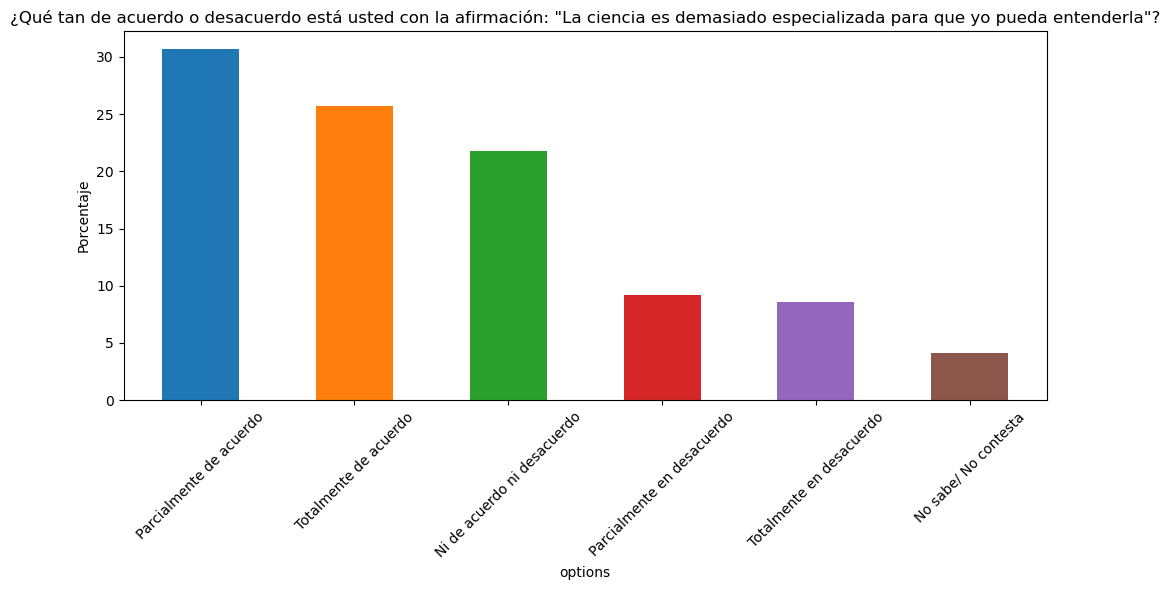

In [321]:
import pandas as pd
import matplotlib.pyplot as plt
import io

data = {'options': ['Parcialmente de acuerdo', 'Totalmente de acuerdo', 'Ni de acuerdo ni desacuerdo', 'Parcialmente en desacuerdo', 'Totalmente en desacuerdo', 'No sabe/ No contesta'],
        'percentage': [30.7, 25.7, 21.8, 9.2, 8.6, 4.1]}

df = pd.DataFrame(data)
df = df.set_index('options')
df.columns = ['p45_1']

# Creating the plot
def create_plot(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    df['p45_1'].sort_values(ascending=False).plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']) # Use different colors
    ax.set_ylabel('Porcentaje')
    ax.set_title('¿Qué tan de acuerdo o desacuerdo está usted con la afirmación: "La ciencia es demasiado especializada para que yo pueda entenderla"?')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    
    # # Convert plot to base64 string
    # img_data = io.BytesIO()
    # fig.savefig(img_data, format='png')
    # img_data.seek(0)
    
    return fig

plot = create_plot(df)
plt.show()

In [271]:
enc_dict[enc_ID]['dataframe'][tmp_var_lst].describe()

,p33,p45_1,p50_4,p34,p36,p52,p11,p37_6,p13_1,p35
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1194.000000,1200.000000,1200.000000,1200.000000
mean,2.633333,2.665833,2.445833,2.900833,2.292500,1.850833,2.771357,3.781667,6.067500,2.542500
std,1.970734,1.697518,1.966033,1.939278,1.457297,1.444641,1.095820,1.678197,13.121411,1.534108
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,3.000000,2.000000,2.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,4.000000,2.000000,2.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4.000000,7.000000,3.000000
max,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,99.000000,9.000000


In [ ]:
# # generación aumentada: prompt + pregunta + documentos 

# query_oneline = query.replace("\n", " ")

# # This prompt is where you can specify any guidance on tone, or what topics the model should stick to, or avoid.
# prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below. 
# Be sure to respond in a complete sentence, being comprehensive, including all relevant background information. 
# However, you are talking to a non-technical audience, so be sure to break down complicated concepts and 
# strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.

# QUESTION: {query_oneline}
# """

# # Add the retrieved documents to the prompt.
# for passage in all_passages:
#     passage_oneline = passage.replace("\n", " ")
#     prompt += f"PASSAGE: {passage_oneline}\n"

# print(prompt)

In [ ]:
# las columnas terminadas en 'a' son aparentemente idénticas a las que no... 

filtered_columns = enc_dict['Ciencia_y_Tecnologia']['dataframe'].filter(regex='^p.*a$')
value_counts_df = pd.DataFrame({col: filtered_columns[col].value_counts() for col in filtered_columns.columns}).fillna(0).astype(int)
filtered_columns, value_counts_df

(      p14_1a  p14_2a  p14_3a  p15_1a  p15_2a  p15_3a  p20_1a  p20_2a  p20_3a  \
 0        3.0     2.0     5.0     9.0     6.0     7.0    10.0     5.0     4.0   
 1        2.0     3.0     4.0    12.0     6.0     NaN     NaN     NaN     NaN   
 2        3.0     5.0     4.0     7.0     2.0     6.0     2.0     6.0    10.0   
 3        3.0     5.0     NaN     2.0     7.0    10.0     6.0    10.0     4.0   
 4        9.0     NaN     NaN    11.0     NaN     NaN     NaN     NaN     NaN   
 ...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
 1195     3.0     4.0     NaN     1.0     NaN     NaN     NaN     NaN     NaN   
 1196     3.0     5.0     NaN     3.0     NaN     NaN     4.0    10.0     NaN   
 1197     3.0     4.0     NaN     2.0     3.0     7.0     NaN     NaN     NaN   
 1198     3.0     5.0     NaN     1.0     2.0     7.0     1.0     4.0    10.0   
 1199     3.0     NaN     NaN     2.0     1.0     NaN     NaN     NaN     NaN   
 
       p29_1a  p29_2a  p29

In [ ]:
filtered_columns.columns.str.rstrip('a')
enc_dict['Ciencia_y_Tecnologia']['dataframe'][filtered_columns.columns.str.rstrip('a')]

,p14_1,p14_2,p14_3,p15_1,p15_2,p15_3,p20_1,p20_2,p20_3,p29_1,p29_2,p29_3,p46_1,p46_2,p46_3,p47_1,p47_2,p47_3,p53,p54
0,3.0,2.0,5.0,9.0,6.0,7.0,10.0,5.0,4.0,10.0,4.0,6.0,10.0,1.0,7.0,3.0,9.0,1.0,2.0,2.0
1,2.0,3.0,4.0,12.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,9.0,3.0,4.0,7.0,2.0,2.0
2,3.0,5.0,4.0,7.0,2.0,6.0,2.0,6.0,10.0,NaN,NaN,NaN,7.0,1.0,10.0,7.0,1.0,10.0,2.0,1.0
3,3.0,5.0,NaN,2.0,7.0,10.0,6.0,10.0,4.0,NaN,NaN,NaN,5.0,4.0,10.0,2.0,6.0,7.0,2.0,2.0
4,9.0,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.0,NaN,NaN,1.0,6.0,10.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,3.0,4.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN,5.0,2.0,NaN,2.0,2.0
1196,3.0,5.0,NaN,3.0,NaN,NaN,4.0,10.0,NaN,NaN,NaN,NaN,8.0,6.0,10.0,8.0,6.0,10.0,2.0,2.0
1197,3.0,4.0,NaN,2.0,3.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,5.0,10.0,2.0,5.0,10.0,2.0,2.0
1198,3.0,5.0,NaN,1.0,2.0,7.0,1.0,4.0,10.0,1.0,4.0,NaN,2.0,9.0,10.0,2.0,9.0,10.0,2.0,2.0


In [110]:
result

Index(['p1_1a_1', 'p1_2a_1', 'p1_3a_1', 'p2_1a_1', 'p2_2a_1', 'p2_3a_1',
       'p14_1a', 'p14_2a', 'p14_3a', 'p15_1a', 'p15_2a', 'p15_3a', 'p20_1a',
       'p20_2a', 'p20_3a', 'p29_1a', 'p29_2a', 'p29_3a', 'p46_1a', 'p46_2a',
       'p46_3a', 'p47_1a', 'p47_2a', 'p47_3a', 'p53a', 'p53aa_1', 'p54a'],
      dtype='object')

In [114]:
result_a = enc_dict['Ciencia_y_Tecnologia']['dataframe'].filter(regex='^p.*a$').columns
base_a = [col.rstrip('_a') for col in result_a]
enc_dict['Ciencia_y_Tecnologia']['dataframe'][base_a].describe()

# base_colnames = [col.rstrip('a_1').rstrip('_a') for col in result]
# matching_colnames = [col for col in enc_dict['Ciencia_y_Tecnologia']['dataframe'].columns if any(base in col for base in base_colnames)]
# result, base_colnames, matching_colnames

,p14_1,p14_2,p14_3,p15_1,p15_2,p15_3,p20_1,p20_2,p20_3,p29_1,p29_2,p29_3,p46_1,p46_2,p46_3,p47_1,p47_2,p47_3,p53,p54
count,1200.000000,623.000000,312.000000,1200.000000,728.000000,457.000000,322.000000,226.000000,153.000000,308.000000,173.000000,87.000000,1200.000000,1006.000000,849.000000,1200.000000,975.000000,802.000000,1200.000000,1200.000000
mean,6.783333,3.762440,4.227564,8.190833,4.295330,5.750547,7.478261,5.420354,6.882353,6.081169,5.369942,6.172414,13.755000,5.516899,6.799764,13.255000,5.502564,7.056110,11.133333,2.110000
std,15.401430,1.487807,1.969905,16.777733,2.920191,3.025318,15.013011,2.988174,3.069247,10.966483,2.724057,2.548173,29.463877,7.160923,2.948049,28.608513,2.780791,2.859261,28.512711,1.316945
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,5.000000,1.000000,2.000000,5.000000,2.000000,3.000000,5.000000,2.000000,2.000000
50%,3.000000,4.000000,4.000000,6.000000,3.000000,6.000000,4.000000,5.000000,7.000000,4.000000,5.000000,6.000000,3.000000,5.000000,7.000000,3.000000,6.000000,8.000000,2.000000,2.000000
75%,5.000000,5.000000,5.000000,10.000000,7.000000,8.000000,8.000000,8.000000,10.000000,6.000000,7.000000,8.000000,7.000000,7.000000,9.000000,7.000000,7.000000,9.000000,2.000000,2.000000
max,99.000000,13.000000,12.000000,99.000000,14.000000,14.000000,99.000000,14.000000,14.000000,99.000000,15.000000,13.000000,99.000000,99.000000,17.000000,99.000000,15.000000,14.000000,99.000000,9.000000


In [115]:
enc_dict['Ciencia_y_Tecnologia']['dataframe'].filter(regex='^p.*a$').describe()


,p14_1a,p14_2a,p14_3a,p15_1a,p15_2a,p15_3a,p20_1a,p20_2a,p20_3a,p29_1a,p29_2a,p29_3a,p46_1a,p46_2a,p46_3a,p47_1a,p47_2a,p47_3a,p53a,p54a
count,1200.000000,623.000000,312.000000,1200.000000,728.000000,457.000000,322.000000,226.000000,153.000000,308.000000,173.000000,87.000000,1200.000000,1006.000000,849.000000,1200.000000,975.000000,802.000000,1200.00000,171.000000
mean,6.783333,3.756019,4.208333,8.180000,4.281593,5.746171,7.391304,5.407080,6.862745,5.925325,5.271676,6.137931,13.751667,5.512922,6.792697,13.241667,5.495385,7.052369,2.96250,12.321637
std,15.401430,1.455069,1.902324,16.774547,2.878864,3.014787,14.982097,2.956386,3.032844,10.883643,2.482768,2.473922,29.463708,7.155093,2.927890,28.608308,2.761894,2.852119,12.33523,27.966504
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.00000,1.000000
25%,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,5.000000,1.000000,2.000000,5.000000,2.000000,3.000000,5.000000,-1.00000,2.000000
50%,3.000000,4.000000,4.000000,6.000000,3.000000,6.000000,4.000000,5.000000,7.000000,4.000000,5.000000,6.000000,3.000000,5.000000,7.000000,3.000000,6.000000,8.000000,-1.00000,4.000000
75%,5.000000,5.000000,5.000000,10.000000,7.000000,8.000000,8.000000,8.000000,10.000000,6.000000,7.000000,8.000000,7.000000,7.000000,9.000000,7.000000,7.000000,9.000000,-1.00000,5.000000
max,99.000000,10.000000,10.000000,99.000000,12.000000,12.000000,99.000000,11.000000,11.000000,99.000000,10.000000,10.000000,99.000000,99.000000,14.000000,99.000000,11.000000,11.000000,99.00000,99.000000


In [ ]:
enc_dict['Ciencia_y_Tecnologia']['metadata']['variable_value_labels']['p16']

{98.0: 'NS', 99.0: 'NC'}

In [ ]:
enc_dict['Ciencia_y_Tecnologia']['dataframe']['p16']

0       5.0
1       2.0
2       6.0
3       7.0
4       6.0
       ... 
1195    3.0
1196    6.0
1197    5.0
1198    8.0
1199    6.0
Name: p16, Length: 1200, dtype: float64

In [ ]:
pregs_dict.values()

dict_values(['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 2° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocies con la palabra CIENCIA? 3° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 2° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocies con la palabra CIENCIA? 3° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  2° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  3° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° M

In [ ]:
from collections import Counter

# Identify non-unique elements in the list
non_unique_elements = [item for item, count in Counter(list(pregs_dict.values())).items() if count > 1]
non_unique_elements

['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN',
 '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 2° MENCIÓN',
 '¿Podría decirme, por favor, tres palabras que asocies con la palabra CIENCIA? 3° MENCIÓN',
 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN',
 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  2° MENCIÓN',
 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  3° MENCIÓN',
 ' 14 Además de la ESCUELA, ¿En qué lugares escucha más hablar sobre ciencia?  1° MENCIÓN',
 ' 14 Además de la ESCUELA, ¿En qué lugares escucha más hablar sobre ciencia?  2° MENCIÓN',
 ' 14 Además de la ESCUELA, ¿En qué lugares escucha más hablar sobre ciencia?  3° MENCIÓN',
 ' 15 Cuando estaba en la escuela o en sus estudios ¿De quién o quienes recibía (recibe) apoyo para realizar

In [ ]:
len(non_unique_elements)

25

### sigue debajo

In [28]:
# crea un ciente de chromadb - y fija document_mode a True

# import chromadb

# DB_NAME = "googlecardb"

# embed_fn = GeminiEmbeddingFunction()
# embed_fn.document_mode = True

# chroma_client = chromadb.Client()
# db = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embed_fn)

# db.add(documents=documents, ids=[str(i) for i in range(len(documents))])

In [29]:
# db.count(), db.peek()

In [30]:
# results = db.get()

# results

# print("IDs:", results["ids"])
# print("Documents:", results["documents"])
# print("Embeddings:", results["embeddings"])
# print("Metadatas:", results["metadatas"])

# # ChromaDB does not store embeddings by default for efficiency reasons.
# # To retrieve embeddings, you need to query the database instead of using `db.get()`.

# query_results = db.query(query_texts=[""], n_results=db.count())
# print("Embeddings:", query_results["embeddings"])

In [31]:
# # Switch to query mode when generating embeddings.
# embed_fn.document_mode = False

# # Search the Chroma DB using the specified query.
# query = "How do you use the touchscreen to play music?"

# result = db.query(query_texts=[query], n_results=1)
# [all_passages] = result["documents"]

# Markdown(all_passages[0])

In [32]:
# # generación aumentada: prompt + pregunta + documentos 

# query_oneline = query.replace("\n", " ")

# # This prompt is where you can specify any guidance on tone, or what topics the model should stick to, or avoid.
# prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below. 
# Be sure to respond in a complete sentence, being comprehensive, including all relevant background information. 
# However, you are talking to a non-technical audience, so be sure to break down complicated concepts and 
# strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.

# QUESTION: {query_oneline}
# """

# # Add the retrieved documents to the prompt.
# for passage in all_passages:
#     passage_oneline = passage.replace("\n", " ")
#     prompt += f"PASSAGE: {passage_oneline}\n"

# print(prompt)

In [33]:
# answer = client.models.generate_content(
#     model="gemini-2.0-flash",
#     contents=prompt)

# Markdown(answer.text)

#### similarity scores

In [34]:
# calcular la similitud entre documentos

texts = [
    'The quick brown fox jumps over the lazy dog.',
    'The quick rbown fox jumps over the lazy dog.',
    'teh fast fox jumps over the slow woofer.',
    'a quick brown fox jmps over lazy dog.',
    'brown fox jumping over dog',
    'fox > dog',
    # Alternative pangram for comparison:
    'The five boxing wizards jump quickly.',
    # Unrelated text, also for comparison:
    'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus et hendrerit massa. Sed pulvinar, nisi a lobortis sagittis, neque risus gravida dolor, in porta dui odio vel purus.',
]


response = client.models.embed_content(
    model='models/text-embedding-004',
    contents=texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))

In [35]:
# el modelo de embeddings como diccionario y los embeddings directos    
response.model_dump(), response.embeddings

({'embeddings': [{'values': [-0.0922682,
     0.012113783,
     -0.0063794684,
     0.0369048,
     0.02203019,
     0.048805293,
     0.0133289965,
     0.021541007,
     0.02705553,
     -0.0043925485,
     -0.011962657,
     0.069833845,
     0.010891116,
     0.06149802,
     0.049922608,
     0.022119658,
     0.0178632,
     0.050096616,
     0.0029887455,
     -0.008278692,
     0.005999019,
     -0.0040636063,
     0.015202278,
     -0.021813663,
     -0.02274539,
     -0.032121718,
     -0.00033075613,
     -0.022031343,
     0.028694874,
     -0.04976425,
     0.025347114,
     0.07245508,
     0.003248612,
     -0.002201165,
     0.059787363,
     -0.0057624904,
     -0.02634191,
     -0.003782781,
     0.048398733,
     0.0066004205,
     -0.05704449,
     -0.022870814,
     -0.058460187,
     0.013212032,
     0.01834201,
     -0.076267265,
     -0.02015255,
     0.014425502,
     0.0024263572,
     -0.011807308,
     0.056245767,
     -0.0031448188,
     0.0013501083,
   

In [36]:
# la longitud de los embeddings es fija
len(response.embeddings[0].values)

768

In [37]:
# truncar datos para visualización

def truncate(t: str, limit: int = 50) -> str:
  """Truncate labels to fit on the chart."""
  if len(t) > limit:
    return t[:limit-3] + '...'
  else:
    return t

truncated_texts = [truncate(t) for t in texts]

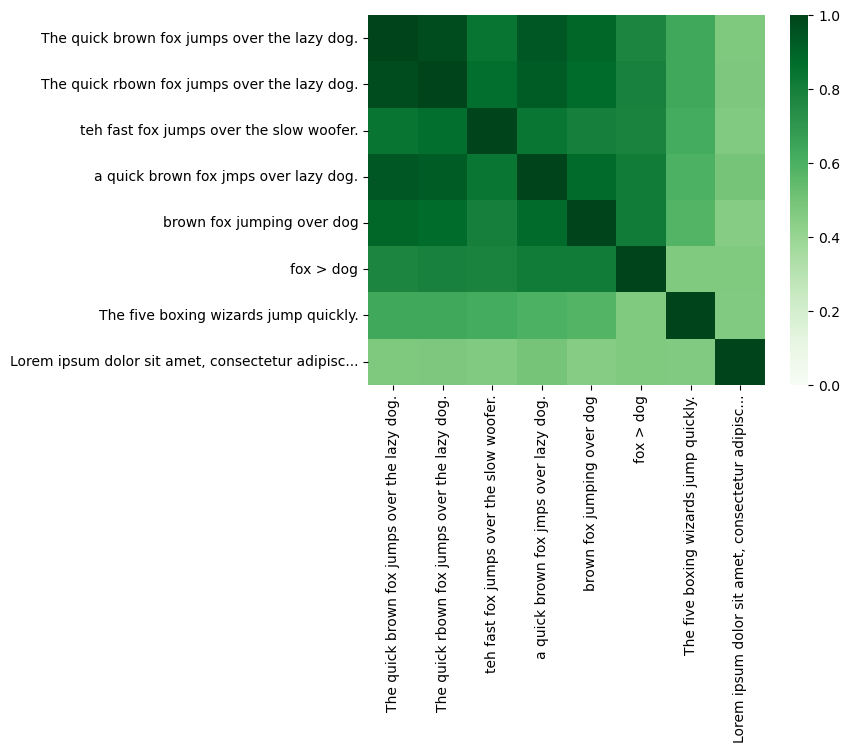

In [38]:
# la similaridad se calcula como el producto punto (inner product) entre los vectores de embedding

import pandas as pd
import seaborn as sns


# Set up the embeddings in a dataframe.
df = pd.DataFrame([e.values for e in response.embeddings], index=truncated_texts)

# la matriz de similardad: 
# Perform the similarity calculation
sim = df @ df.T
# Draw!
sns.heatmap(sim, vmin=0, vmax=1, cmap="Greens");

In [39]:
# sim is a similarity matrix calculated as the dot product of embedding vectors.
# Each entry in sim represents the similarity score between two text embeddings.
sim['The quick brown fox jumps over the lazy dog.'].sort_values(ascending=False)

The quick brown fox jumps over the lazy dog.          0.999999
The quick rbown fox jumps over the lazy dog.          0.975623
a quick brown fox jmps over lazy dog.                 0.939730
brown fox jumping over dog                            0.894507
teh fast fox jumps over the slow woofer.              0.842152
fox > dog                                             0.776455
The five boxing wizards jump quickly.                 0.635346
Lorem ipsum dolor sit amet, consectetur adipisc...    0.472174
Name: The quick brown fox jumps over the lazy dog., dtype: float64

#### clasificación de embeddings con Keras

In [40]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset="train")
newsgroups_test = fetch_20newsgroups(subset="test")

# View list of class names for dataset
newsgroups_train.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [41]:
print(newsgroups_train.data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [42]:
# # preprocesamiento como un mensaje anónimo

# import email
# import re

# import pandas as pd


# def preprocess_newsgroup_row(data):
#     # Extract only the subject and body
#     msg = email.message_from_string(data)
#     text = f"{msg['Subject']}\n\n{msg.get_payload()}"
#     # Strip any remaining email addresses
#     text = re.sub(r"[\w\.-]+@[\w\.-]+", "", text)
#     # Truncate each entry to 5,000 characters
#     text = text[:5000]

#     return text


# def preprocess_newsgroup_data(newsgroup_dataset):
#     # Put data points into dataframe
#     df = pd.DataFrame(
#         {"Text": newsgroup_dataset.data, "Label": newsgroup_dataset.target}
#     )
#     # Clean up the text
#     df["Text"] = df["Text"].apply(preprocess_newsgroup_row)
#     # Match label to target name index
#     df["Class Name"] = df["Label"].map(lambda l: newsgroup_dataset.target_names[l])

#     return df

In [43]:
# # Apply preprocessing function to training and test datasets
# df_train = preprocess_newsgroup_data(newsgroups_train)
# df_test = preprocess_newsgroup_data(newsgroups_test)

# df_train.head()

,Text,Label,Class Name
0,WHAT car is this!?\n\n I was wondering if anyo...,7,rec.autos
1,SI Clock Poll - Final Call\n\nA fair number of...,4,comp.sys.mac.hardware
2,"PB questions...\n\nwell folks, my mac plus fin...",4,comp.sys.mac.hardware
3,Re: Weitek P9000 ?\n\nRobert J.C. Kyanko () wr...,1,comp.graphics
4,Re: Shuttle Launch Question\n\nFrom article <>...,14,sci.space


In [44]:
# # muestra de datos y selección de mensajes de ciencia
# def sample_data(df, num_samples, classes_to_keep):
#     # Sample rows, selecting num_samples of each Label.
#     df = (
#         df.groupby("Label")[df.columns]
#         .apply(lambda x: x.sample(num_samples))
#         .reset_index(drop=True)
#     )

#     df = df[df["Class Name"].str.contains(classes_to_keep)]

#     # We have fewer categories now, so re-calibrate the label encoding.
#     df["Class Name"] = df["Class Name"].astype("category")
#     df["Encoded Label"] = df["Class Name"].cat.codes

#     return df

In [45]:
# TRAIN_NUM_SAMPLES = 100
# TEST_NUM_SAMPLES = 25
# # Class name should contain 'sci' to keep science categories.
# # Try different labels from the data - see newsgroups_train.target_names
# CLASSES_TO_KEEP = "sci"

# df_train = sample_data(df_train, TRAIN_NUM_SAMPLES, CLASSES_TO_KEEP)
# df_test = sample_data(df_test, TEST_NUM_SAMPLES, CLASSES_TO_KEEP)

In [46]:
# df_train.value_counts("Class Name")

Class Name
sci.crypt          100
sci.electronics    100
sci.med            100
sci.space          100
Name: count, dtype: int64

#### clasificación

In [47]:
## el modelo de embeddings se puede usar para varias tareas

# Task types
# The text-embedding-004 model supports a task type parameter that generates embeddings tailored for the specific task.

# Task Type	Description
# RETRIEVAL_QUERY	Specifies the given text is a query in a search/retrieval setting.
# RETRIEVAL_DOCUMENT	Specifies the given text is a document in a search/retrieval setting.
# SEMANTIC_SIMILARITY	Specifies the given text will be used for Semantic Textual Similarity (STS).
# CLASSIFICATION	Specifies that the embeddings will be used for classification.
# CLUSTERING	Specifies that the embeddings will be used for clustering.
# FACT_VERIFICATION	Specifies that the given text will be used for fact verification.
# For this example you will be performing classification.

In [48]:
# # clasificación de texto

# from google.api_core import retry
# import tqdm
# from tqdm.rich import tqdm as tqdmr
# import warnings

# # Add tqdm to Pandas...
# tqdmr.pandas()

# # ...But suppress the experimental warning.
# warnings.filterwarnings("ignore", category=tqdm.TqdmExperimentalWarning)

# # Define a helper to retry when per-minute quota is reached.
# is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

# @retry.Retry(predicate=is_retriable, timeout=300.0)
# def embed_fn(text: str) -> list[float]:
#     # You will be performing classification, so set task_type accordingly.
#     response = client.models.embed_content(
#         model="models/text-embedding-004",
#         contents=text,
#         config=types.EmbedContentConfig(
#             task_type="classification",
#         ),
#     )

#     return response.embeddings[0].values


# def create_embeddings(df):
#     df["Embeddings"] = df["Text"].progress_apply(embed_fn)
#     return df

In [49]:
#toma aprox 4 -8 mins

# df_train = create_embeddings(df_train)
# df_test = create_embeddings(df_test)

In [50]:
# df_train.head()

In [51]:
# # construcción de un modelo de clasificación con keras

# import keras
# from keras import layers


# def build_classification_model(input_size: int, num_classes: int) -> keras.Model:
#     return keras.Sequential(
#         [
#             layers.Input([input_size], name="embedding_inputs"),
#             layers.Dense(input_size, activation="relu", name="hidden"),
#             layers.Dense(num_classes, activation="softmax", name="output_probs"),
#         ]
#     )

In [52]:
# # Derive the embedding size from observing the data. The embedding size can also be specified
# # with the `output_dimensionality` parameter to `embed_content` if you need to reduce it.
# embedding_size = len(df_train["Embeddings"].iloc[0])

# classifier = build_classification_model(
#     embedding_size, len(df_train["Class Name"].unique())
# )
# classifier.summary()

# classifier.compile(
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     metrics=["accuracy"],
# )

In [53]:
# # modelo de clasificación
# # The model is compiled and ready to train.

# import numpy as np


# NUM_EPOCHS = 20
# BATCH_SIZE = 32

# # Split the x and y components of the train and validation subsets.
# y_train = df_train["Encoded Label"]
# x_train = np.stack(df_train["Embeddings"])
# y_val = df_test["Encoded Label"]
# x_val = np.stack(df_test["Embeddings"])

# # Specify that it's OK to stop early if accuracy stabilises.
# early_stop = keras.callbacks.EarlyStopping(monitor="accuracy", patience=3)

# # Train the model for the desired number of epochs.
# history = classifier.fit(
#     x=x_train,
#     y=y_train,
#     validation_data=(x_val, y_val),
#     callbacks=[early_stop],
#     batch_size=BATCH_SIZE,
#     epochs=NUM_EPOCHS,
# )

In [54]:
# evaluación del modelo

# classifier.evaluate(x=x_val, y=y_val, return_dict=True)

In [55]:
# def make_prediction(text: str) -> list[float]:
#     """Infer categories from the provided text."""
#     # Remember that the model takes embeddings as input, so calculate them first.
#     embedded = embed_fn(new_text)

#     # And recall that the input must be batched, so here they are wrapped as a
#     # list to provide a batch of 1.
#     inp = np.array([embedded])

#     # And un-batched here.
#     [result] = classifier.predict(inp)
#     return result

In [56]:
# # This example avoids any space-specific terminology to see if the model avoids
# # biases towards specific jargon.
# new_text = """
# First-timer looking to get out of here.

# Hi, I'm writing about my interest in travelling to the outer limits!

# What kind of craft can I buy? What is easiest to access from this 3rd rock?

# Let me know how to do that please.
# """

# result = make_prediction(new_text)

# for idx, category in enumerate(df_test["Class Name"].cat.categories):
#     print(f"{category}: {result[idx] * 100:0.2f}%")